# 🏛️ Legal Case Precedent Recommendation System
### Heterogeneous Attention Network (HAN) on Indian Legal Citation Graph

**Full Pipeline:**
```
Indian Kanoon API → Raw Case Text + Metadata
       ↓
NLP Pipeline → Legal Entity Extraction + InLegalBERT Embeddings
       ↓
Heterogeneous Graph → Nodes: Case, Statute, Court, Judge
                   → Edges: cites, invokes, heard_by, decided_by
       ↓
HAN + SC Importance Layer → Case Embeddings
       ↓
BPR Link Prediction → Top-K Precedent Recommendations
```

**Why HAN for Legal Graph?**
A legal citation network is naturally heterogeneous. Cases link to other cases,
statutes, courts, and judges — each relationship carries different semantics.
HAN's semantic-level attention learns WHICH of these relationships matters most
for finding relevant precedents. The Supreme Court importance layer gives extra
weight to SC rulings, which are binding on all lower courts in India.

──────────────────────────────────────────────────────────────────────────────
SECTION 0: SETUP & DEPENDENCIES
──────────────────────────────────────────────────────────────────────────────

## Cell 1 — Install Dependencies
Installs all required packages. On **Colab GPU (T4/A100)**: uncomment the CUDA
lines and comment the CPU lines. PyTorch Geometric needs special extension wheels
(scatter, sparse) matching your exact torch+CUDA version.
spaCy's `en_core_web_sm` model is needed for tokenization and basic NER.

In [1]:
# ─── COLAB GPU (uncomment these) ──────────────────────────────────────────────
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install -q transformers spacy pdfplumber networkx matplotlib seaborn
!pip install -q scikit-learn tqdm python-dotenv
!python -m spacy download en_core_web_sm -q

# ─── LOCAL CPU (uncomment these) ──────────────────────────────────────────────
# pip install torch torch_geometric transformers spacy pdfplumber
# pip install networkx matplotlib seaborn scikit-learn tqdm python-dotenv
# pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.3.0+cpu.html
# python -m spacy download en_core_web_sm

print("✅ If running fresh: restart Colab runtime after installs before proceeding.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python i

## Cell 2 — Core Imports
Imports every library used in this notebook. Grouped by purpose so it is clear
what each block is for. If any import fails, check your install from Cell 1.

In [2]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os, re, json, time, logging
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import List, Dict, Tuple, Optional

# ── Numerical & DataFrame ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# ── ML Utilities ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── NLP ───────────────────────────────────────────────────────────────────────
import spacy
import pdfplumber
from transformers import AutoTokenizer, AutoModel

# ── PyTorch & PyG ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import HeteroData
from torch_geometric.nn import HANConv
from torch_geometric.transforms import RandomLinkSplit, ToUndirected

# ── Utilities ─────────────────────────────────────────────────────────────────
from tqdm import tqdm
from dotenv import load_dotenv
import requests

load_dotenv()
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger(__name__)

print("✅ All imports successful.")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


✅ All imports successful.


## Cell 3 — Global Config & Reproducibility
Centralised config dict so every hyperparameter lives in ONE place — no magic
numbers scattered across cells. Setting seeds for torch, numpy, and Python
ensures identical results across runs (critical for reproducibility in a
portfolio project where you report metrics).

In [3]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
import random; random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Running on: {DEVICE}")

# ── Config ────────────────────────────────────────────────────────────────────
CFG = {
    # Data
    "cache_dir"       : Path("./cache"),
    "embed_model"     : "law-ai/InLegalBERT",   # fallback: "bert-base-uncased"
    "embed_dim"       : 768,
    "max_seq_len"     : 512,
    "bert_stride"     : 256,               # sliding window stride for long texts

    # Graph
    "min_citations"   : 1,                 # drop cases with 0 citations
    "add_reverse_edges": True,

    # Model
    "hidden_dim"      : 128,
    "out_dim"         : 64,
    "han_heads"       : 4,
    "han_layers"      : 2,
    "dropout"         : 0.4,

    # Training
    "lr"              : 1e-3,
    "weight_decay"    : 1e-4,             # L2 regularisation — key anti-overfit lever
    "epochs"          : 200,
    "patience"        : 15,               # early stopping patience
    "neg_sample_ratio": 4,               # negatives per positive (BPR)
    "batch_size"      : 512,

    # Evaluation
    "k_values"        : [5, 10, 20],
}

CFG["cache_dir"].mkdir(exist_ok=True)
print("✅ Config ready.")



🔧 Running on: cuda
✅ Config ready.


## Cell 4 — Indian Kanoon API Client
Indian Kanoon provides a REST API for searching and fetching Indian court
judgements. You need to register at https://api.indiankanoon.org and get a token.

**Key endpoints:**
- `POST /search/` — search for cases by query + filters
- `GET /doc/{docid}/` — fetch full judgement text + metadata

The client wraps these with:
- Automatic retry with exponential backoff (avoid rate limits)
- Local JSON caching (avoid re-fetching the same case)
- Structured parsing of the API response

In [5]:
import json
import logging as log
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import List, Optional
import requests
from tqdm import tqdm

# Configure default logging
log.basicConfig(level=log.INFO)

# Dummy config setup (ensure this matches your environment configuration)
CFG = {"cache_dir": Path("./ik_cache")}


@dataclass
class Case:
    """Schema for a single legal case. Every field maps to what Indian Kanoon
    returns or what we extract via NLP. Keeping it a dataclass makes
    serialisation (JSON) and validation trivial."""

    doc_id: str
    title: str
    court: str  # raw court name from API
    court_tier: int = 2  # 0=SC, 1=HC, 2=Lower — assigned later
    year: int = 0
    judges: List[str] = field(default_factory=list)
    text: str = ""  # full judgement text
    summary: str = ""  # first ~1000 chars — used for embedding
    citations: List[str] = field(default_factory=list)  # other doc_ids cited
    statutes: List[str] = field(default_factory=list)  # statutes mentioned
    embedding: Optional[List[float]] = None  # BERT vector (filled later)


class IndianKanoonClient:
    """Thin wrapper around the Indian Kanoon API.

    ─────────────────────────────────────────
    Usage:
        client = IndianKanoonClient(api_token="YOUR_TOKEN_HERE")
        cases  = client.search_and_fetch(query="right to privacy", n=70)
    """

    BASE_URL = "https://api.indiankanoon.org"  # Removed trailing slash

    def __init__(self, api_token: str, cache_dir: Path = CFG["cache_dir"]):
        self.headers = {"Authorization": f"Token {api_token}"}
        self.cache_dir = cache_dir
        self.cache_dir.mkdir(exist_ok=True)

    # ── Internal helpers ──────────────────────────────────────────────────────

    def _get(self, endpoint: str, params: dict = None, retries: int = 3):
        """GET with retry + exponential backoff."""
        # Clean endpoints to avoid double slashes
        url = f"{self.BASE_URL}/{endpoint.lstrip('/')}"
        for attempt in range(retries):
            try:
                r = requests.get(
                    url, headers=self.headers, params=params, timeout=15
                )
                r.raise_for_status()
                return r.json()
            except requests.RequestException as e:
                wait = 2**attempt
                log.warning(
                    f"Attempt {attempt+1} failed ({e}). Retrying in {wait}s…"
                )
                time.sleep(wait)
        raise RuntimeError(
            f"API call to {endpoint} failed after {retries} retries."
        )

    def _post(self, endpoint: str, data: dict = None, retries: int = 3):
        """POST with retry."""
        # Clean endpoints to avoid double slashes
        url = f"{self.BASE_URL}/{endpoint.lstrip('/')}"
        for attempt in range(retries):
            try:
                r = requests.post(
                    url, headers=self.headers, data=data, timeout=15
                )
                r.raise_for_status()
                return r.json()
            except requests.RequestException as e:
                wait = 2**attempt
                log.warning(
                    f"Attempt {attempt+1} failed ({e}). Retrying in {wait}s…"
                )
                time.sleep(wait)
        raise RuntimeError(f"API call failed after {retries} retries.")

    def _cache_path(self, doc_id: str) -> Path:
        return self.cache_dir / f"{doc_id}.json"

    # ── Public methods ────────────────────────────────────────────────────────

    def search(self, query: str, page: int = 1) -> List[str]:
        """Search cases and return list of doc_ids."""
        resp = self._post("/search/", data={"formInput": query, "pagenum": page})
        docs = resp.get("docs", [])
        return [str(d["tid"]) for d in docs]

    def fetch_doc(self, doc_id: str) -> Optional[Case]:
        """Fetch a single judgement. Returns cached version if available."""
        cache_file = self._cache_path(doc_id)

        # ── Cache hit ─────────────────────────────────────────────────────────
        if cache_file.exists():
            with open(cache_file) as f:
                data = json.load(f)
            return Case(**data)

        # ── Cache miss: hit API ───────────────────────────────────────────────
        try:
            resp = self._post(f"/doc/{doc_id}/")
        except RuntimeError:
            return None

        # ── Data Extraction Fix ───────────────────────────────────────────────
        # The API returns a flat dictionary. We extract directly from `resp`.

        title = resp.get("title", "Unknown")
        court = resp.get("docsource", "Unknown Court")

        # The judgment text can sometimes be stored under 'judgment' or 'doc'
        text = resp.get("judgment") or resp.get("doc") or ""

        # Safely extract the year from publishdate (e.g., "2018-05-12" -> 2018)
        pub_date = str(resp.get("publishdate") or "0000")
        try:
            year = int(pub_date[:4])
        except ValueError:
            year = 0

        case = Case(
            doc_id=doc_id,
            title=title,
            court=court,
            year=year,
            text=text,
            summary=text[:1000],
        )

        # Cache to disk
        with open(cache_file, "w") as f:
            json.dump(asdict(case), f, indent=2)

        time.sleep(0.5)  # be polite to the API
        return case

    def search_and_fetch(self, query: str, n: int = 100) -> List[Case]:
        """End-to-end: search → fetch each doc → return list of Case objects."""
        doc_ids, page = [], 1
        while len(doc_ids) < n:
            ids = self.search(query, page)
            if not ids:
                break
            doc_ids.extend(ids)
            page += 1

        doc_ids = doc_ids[:n]
        cases = []
        for did in tqdm(doc_ids, desc="Fetching cases"):
            c = self.fetch_doc(did)
            if c:
                cases.append(c)
        return cases


# ── Token Initialization ──────────────────────────────────────────────────────
# Cleaned from a tuple to a single string parameter assignment
API_TOKEN = "9612f2f2dda258b990f7bf9439093ca16a8ca27c"

# Set a placeholder fallback check condition
if API_TOKEN and API_TOKEN != "YOUR_TOKEN_HERE":
    client = IndianKanoonClient(api_token=API_TOKEN)

    # ── Fetch cases across multiple legal domains ──────────────────────────────
    queries = [
        "fundamental rights Article 21",  # Constitutional
        "right to privacy",
        "Section 302 IPC murder",  # Criminal
        "cheque dishonour Section 138 NI Act",  # Commercial
        "land acquisition compensation",  # Property
        "environmental pollution PIL",  # Environmental
    ]
    all_cases: List[Case] = []
    for q in queries:
        fetched = client.search_and_fetch(q, n=70)
        all_cases.extend(fetched)
        time.sleep(1)

    # Save full dataset
    with open(CFG["cache_dir"] / "all_cases.json", "w") as f:
        json.dump([asdict(c) for c in all_cases], f, indent=2)

    print(f"✅ Fetched {len(all_cases)} cases from Indian Kanoon.")
else:
    print(
        "⚠️  API token not set — will use OFFLINE SAMPLE DATA in the next cell."
    )

Fetching cases: 100%|██████████| 70/70 [00:51<00:00,  1.36it/s]


✅ Fetched 420 cases from Indian Kanoon.


## Cell 5 — Offline Sample Data
If you don't have an API token yet (or want to develop + test the pipeline
without burning API quota), this cell provides realistic sample cases.
The structure exactly mirrors what the API returns, so you can swap in real
data later with zero code changes.

Each sample case has: doc_id, title, court, year, judges, text, citations,
and statute mentions. Citations reference other cases in the same list,
creating a real (small) citation graph.

In [ ]:
SAMPLE_CASES_RAW = [
    {
        "doc_id": "SC_001", "title": "K.S. Puttaswamy v. Union of India",
        "court": "Supreme Court of India", "year": 2017,
        "judges": ["D.Y. Chandrachud", "J.S. Khehar", "R.K. Agrawal"],
        "text": (
            "The right to privacy is a fundamental right under Article 21 of the "
            "Constitution of India. The earlier judgement in M.P. Sharma v. Satish Chandra "
            "AIR 1954 SC 300 and Kharak Singh v. State of U.P. AIR 1963 SC 1295 are "
            "overruled to the extent they are inconsistent with this judgement. "
            "Section 66A of the Information Technology Act, 2000 was challenged in "
            "Shreya Singhal v. Union of India (2015) 5 SCC 1. The State must justify "
            "any interference with privacy under Article 14, 19 and 21. "
            "Personal data protection is an essential component of the right to privacy."
        ),
        "citations": ["SC_002", "SC_003", "SC_004"],
        "statutes": ["Article 21", "Information Technology Act 2000", "Article 14", "Article 19"],
    },
    {
        "doc_id": "SC_002", "title": "Maneka Gandhi v. Union of India",
        "court": "Supreme Court of India", "year": 1978,
        "judges": ["Y.V. Chandrachud", "V.R. Krishna Iyer", "P.N. Bhagwati"],
        "text": (
            "The procedure established by law under Article 21 must be fair, just and "
            "reasonable. The right to go abroad is part of the right to personal liberty. "
            "Articles 14, 19 and 21 are not mutually exclusive and must be read together. "
            "This judgement expanded the scope of Article 21 beyond mere physical detention. "
            "The Passport Act, 1967 imposes restrictions that must meet constitutional "
            "standards. State action must satisfy the test of reasonableness under Article 14."
        ),
        "citations": ["SC_005", "SC_006"],
        "statutes": ["Article 21", "Article 14", "Article 19", "Passport Act 1967"],
    },
    {
        "doc_id": "SC_003", "title": "Shreya Singhal v. Union of India",
        "court": "Supreme Court of India", "year": 2015,
        "judges": ["J. Chelameswar", "R.F. Nariman"],
        "text": (
            "Section 66A of the Information Technology Act, 2000 is struck down as "
            "unconstitutional for being vague and overbroad, violating Article 19(1)(a). "
            "Freedom of speech and expression online cannot be abridged by vague laws. "
            "Discussion, advocacy and incitement are distinct. Only incitement to imminent "
            "lawless action can be restricted under Article 19(2). Section 79 read with "
            "rules is read down to be constitutional. Intermediary liability limited."
        ),
        "citations": ["SC_002", "SC_007"],
        "statutes": ["Section 66A IT Act", "Article 19", "Article 19(2)", "Section 79 IT Act"],
    },
    {
        "doc_id": "SC_004", "title": "Navtej Singh Johar v. Union of India",
        "court": "Supreme Court of India", "year": 2018,
        "judges": ["D.Y. Chandrachud", "R.F. Nariman", "A.M. Khanwilkar"],
        "text": (
            "Section 377 of the Indian Penal Code, 1860 is unconstitutional to the extent "
            "it criminalises consensual same-sex relations between adults. The right to "
            "dignity under Article 21 includes the right to sexual orientation. "
            "Suresh Kumar Koushal v. Naz Foundation (2013) 15 SCC 480 is overruled. "
            "Constitutional morality must prevail over social morality. "
            "K.S. Puttaswamy (Privacy judgement) affirms the right to identity."
        ),
        "citations": ["SC_001", "SC_002", "SC_008"],
        "statutes": ["Section 377 IPC", "Article 21", "Article 14", "Article 15"],
    },
    {
        "doc_id": "SC_005", "title": "A.K. Gopalan v. State of Madras",
        "court": "Supreme Court of India", "year": 1950,
        "judges": ["H.J. Kania", "S. Fazl Ali", "M.C. Mahajan"],
        "text": (
            "Article 21 of the Constitution deals only with personal liberty in a "
            "narrow sense. Preventive Detention Act, 1950 is substantially valid. "
            "The term 'procedure established by law' in Article 21 means any procedure "
            "established by a valid law, unlike American due process. Articles 19 and 21 "
            "are mutually exclusive compartments. This interpretation was later overruled "
            "in Maneka Gandhi v. Union of India (1978)."
        ),
        "citations": ["SC_006"],
        "statutes": ["Article 21", "Preventive Detention Act 1950", "Article 19"],
    },
    {
        "doc_id": "HC_001", "title": "Naz Foundation v. Govt. of NCT of Delhi",
        "court": "Delhi High Court", "year": 2009,
        "judges": ["A.P. Shah", "S. Muralidhar"],
        "text": (
            "Section 377 IPC in so far as it criminalises consensual sexual acts of "
            "adults in private is violative of Articles 21, 14 and 15 of the Constitution. "
            "The right to health includes sexual health. Right to dignity is fundamental. "
            "Criminalization of consensual same-sex conduct is unconstitutional. "
            "The Division Bench read down Section 377 to exclude adult consensual acts."
        ),
        "citations": ["SC_002", "SC_005", "HC_002"],
        "statutes": ["Section 377 IPC", "Article 21", "Article 14", "Article 15"],
    },
    {
        "doc_id": "HC_002", "title": "Common Cause v. Union of India (Passive Euthanasia)",
        "court": "Delhi High Court", "year": 2014,
        "judges": ["B.D. Ahmed", "Siddharth Mridul"],
        "text": (
            "The right to die with dignity is a fundamental right under Article 21. "
            "Passive euthanasia may be permitted in exceptional circumstances subject to "
            "safeguards. Advance medical directives should be recognised. "
            "Aruna Shanbaug v. Union of India (2011) 4 SCC 454 discussed. "
            "The matter was referred to a larger bench of the Supreme Court."
        ),
        "citations": ["SC_002", "SC_003"],
        "statutes": ["Article 21", "Article 32"],
    },
    {
        "doc_id": "SC_006", "title": "Romesh Thappar v. State of Madras",
        "court": "Supreme Court of India", "year": 1950,
        "judges": ["H.J. Kania", "S. Fazl Ali"],
        "text": (
            "Freedom of speech and expression includes freedom to propagate ideas "
            "through any medium. The Madras Maintenance of Public Order Act, 1949 "
            "imposing pre-censorship on a journal was struck down. "
            "Restrictions on free speech must fall within the exceptions in Article 19(2). "
            "Public order in Article 19(2) is different from security of the State. "
            "Restrictions must be for one of the grounds specified in Article 19(2)."
        ),
        "citations": ["SC_005"],
        "statutes": ["Article 19", "Article 19(2)", "Article 19(1)(a)"],
    },
    {
        "doc_id": "SC_007", "title": "Bennett Coleman v. Union of India",
        "court": "Supreme Court of India", "year": 1972,
        "judges": ["A.N. Ray", "D.G. Palekar", "H.R. Khanna"],
        "text": (
            "Newsprint policy imposing restrictions on the number of pages is "
            "violative of Article 19(1)(a). Freedom of press is included in Article 19(1)(a). "
            "Direct restrictions and those that have the effect of restricting speech "
            "are both covered by Article 19. The Press and Registration of Books Act, 1867 "
            "must be read consistently with fundamental rights. Reader's right to read "
            "is included in freedom of expression."
        ),
        "citations": ["SC_006"],
        "statutes": ["Article 19", "Article 19(1)(a)", "Press and Registration of Books Act 1867"],
    },
    {
        "doc_id": "SC_008", "title": "NALSA v. Union of India",
        "court": "Supreme Court of India", "year": 2014,
        "judges": ["K.S. Radhakrishnan", "A.K. Sikri"],
        "text": (
            "Transgender persons have the right to decide their self-identified gender. "
            "The State must grant legal recognition of gender identity. Fundamental rights "
            "under Articles 14, 15, 16, 19 and 21 fully apply to transgender persons. "
            "Hijras, eunuchs etc. to be treated as third gender. "
            "Horizontal reservation in OBC category for transgender persons directed. "
            "Right to dignity and bodily integrity under Article 21."
        ),
        "citations": ["SC_002", "SC_004"],
        "statutes": ["Article 21", "Article 14", "Article 15", "Article 16", "Article 19"],
    },
    {
        "doc_id": "DC_001", "title": "State v. Ram Prasad (Murder Trial)",
        "court": "Sessions Court Delhi", "year": 2019,
        "judges": ["Rajeev Kumar Sharma"],
        "text": (
            "The accused is charged under Section 302 of the Indian Penal Code, 1860 "
            "for murder. The prosecution has proved its case beyond reasonable doubt. "
            "Eye witness testimony corroborated by forensic evidence. "
            "The accused is convicted under Section 302 IPC and sentenced to life "
            "imprisonment. Right of appeal under CrPC Section 374 explained."
        ),
        "citations": ["SC_006"],
        "statutes": ["Section 302 IPC", "Section 374 CrPC", "Indian Evidence Act 1872"],
    },
    {
        "doc_id": "SC_009", "title": "Olga Tellis v. Bombay Municipal Corporation",
        "court": "Supreme Court of India", "year": 1985,
        "judges": ["Y.V. Chandrachud", "O. Chinnappa Reddy"],
        "text": (
            "The right to livelihood is part of the right to life under Article 21. "
            "Pavement dwellers cannot be evicted without a hearing. "
            "The right to life includes the right to the means necessary to live. "
            "Procedure for eviction must be fair and reasonable. "
            "Slum dwellers have a right to be heard before demolition of their dwellings. "
            "The Bombay Municipal Corporation Act must be read consistently with Article 21."
        ),
        "citations": ["SC_002", "SC_005"],
        "statutes": ["Article 21", "Article 14", "Bombay Municipal Corporation Act"],
    },
    {
        "doc_id": "SC_010", "title": "M.C. Mehta v. Union of India (Oleum Gas Leak)",
        "court": "Supreme Court of India", "year": 1987,
        "judges": ["P.N. Bhagwati", "E.S. Venkataramiah", "Ranganath Misra"],
        "text": (
            "Absolute liability for hazardous industries causing harm to workers and "
            "public is established as a new rule of law in India, extending beyond "
            "Rylands v. Fletcher. An enterprise engaged in hazardous activity is "
            "absolutely liable to compensate all those who are harmed. "
            "No exceptions apply in absolute liability unlike strict liability. "
            "The Environmental Protection Act, 1986 and Article 21 support this rule. "
            "Compensation must be correlated to the magnitude of the enterprise."
        ),
        "citations": ["SC_002", "SC_009"],
        "statutes": ["Article 21", "Environmental Protection Act 1986", "Article 32"],
    },
]

# ── Load and instantiate Case objects ─────────────────────────────────────────
# If you already fetched from API, load from cache instead:
cache_file = CFG["cache_dir"] / "all_cases.json"
if cache_file.exists():
    with open(cache_file) as f:
        raw = json.load(f)
    all_cases = [Case(**c) for c in raw]
    print(f"✅ Loaded {len(all_cases)} cases from API cache.")
else:
    all_cases = [Case(**c) for c in SAMPLE_CASES_RAW]
    print(f"✅ Using {len(all_cases)} offline sample cases.")

# Quick sanity check
df_cases = pd.DataFrame([{
    "doc_id": c.doc_id, "title": c.title[:50],
    "court": c.court, "year": c.year,
    "n_citations": len(c.citations), "n_statutes": len(c.statutes)
} for c in all_cases])
print(df_cases.to_string(index=False))


## Cell 6 — PDF Extractor
Indian Kanoon sometimes provides PDF downloads of full judgements, and you may
also have your own collection of judgement PDFs. `pdfplumber` handles both
text-based and semi-structured legal PDFs better than `PyPDF2` — it preserves
columns and handles the typical two-column Indian court format.

The extractor:
1. Reads all pages and joins their text
2. Removes headers (page numbers, cause titles that repeat on every page)
3. Strips boilerplate footer text common in Indian court PDFs

In [6]:


# ──────────────────────────────────────────────────────────────────────────────
# SECTION 2: PDF & TEXT EXTRACTION
# ──────────────────────────────────────────────────────────────────────────────

class LegalPDFExtractor:
    """
    Extracts clean text from legal judgement PDFs.
    Handles common Indian court PDF patterns: cause-list headers, page stamps,
    multi-column layouts, and repeated bench/registry headers.
    """

    # Patterns that appear on every page but carry no legal content
    BOILERPLATE_PATTERNS = [
        r"Page\s+\d+\s+of\s+\d+",
        r"^\s*\d+\s*$",                          # standalone page numbers
        r"IN THE (SUPREME|HIGH) COURT OF.*?\n",
        r"REPORTABLE|NON-REPORTABLE",
        r"^\s*\*+\s*$",
        r"Signature Not Verified",
        r"Digitally signed by.*?\n",
    ]

    def extract(self, pdf_path: str) -> str:
        """Extract and clean text from a PDF file."""
        raw_pages = []
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text(x_tolerance=3, y_tolerance=3)
                if text:
                    raw_pages.append(text)

        full_text = "\n".join(raw_pages)
        return self._clean_pdf_text(full_text)

    def _clean_pdf_text(self, text: str) -> str:
        for pattern in self.BOILERPLATE_PATTERNS:
            text = re.sub(pattern, "", text, flags=re.MULTILINE | re.IGNORECASE)
        # Collapse multiple blank lines
        text = re.sub(r"\n{3,}", "\n\n", text)
        # Remove hyphenated line breaks (common in PDFs)
        text = re.sub(r"-\n([a-z])", r"\1", text)
        return text.strip()

    def batch_extract(self, pdf_dir: str) -> Dict[str, str]:
        """Extract text from all PDFs in a directory. Returns {filename: text}."""
        results = {}
        pdf_files = list(Path(pdf_dir).glob("*.pdf"))
        for pdf_file in tqdm(pdf_files, desc="Extracting PDFs"):
            try:
                results[pdf_file.stem] = self.extract(str(pdf_file))
            except Exception as e:
                log.warning(f"Failed to extract {pdf_file.name}: {e}")
        return results


# ── Usage ─────────────────────────────────────────────────────────────────────
# pdf_extractor = LegalPDFExtractor()
# pdf_texts = pdf_extractor.batch_extract("./judgement_pdfs/")
# Merge extracted text into matching cases: case.text = pdf_texts.get(case.doc_id, case.text)

print("✅ PDF extractor ready.")




✅ PDF extractor ready.


## Cell 7 — Legal Text Cleaner
Raw judgement text is messy: it contains HTML artifacts (if scraped), citation
noise, repeated phrases, and encoding issues. This cleaner normalises text
before it reaches the NER model and BERT embedder.

Steps:
1. Strip HTML tags (in case text came from web scraping)
2. Normalise whitespace and line endings
3. Remove common legal noise (Vs., Ltd., etc.) that confuses NER
4. Normalise citation styles (so the extractor has a consistent surface form)

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 3: LEGAL NLP PIPELINE
# ──────────────────────────────────────────────────────────────────────────────
class LegalTextCleaner:
    """Normalises raw legal text for NLP processing."""

    # Statute short-forms → full names (helps statute entity linking later)
    STATUTE_ALIASES = {
        r"\bIPC\b"   : "Indian Penal Code",
        r"\bCrPC\b"  : "Code of Criminal Procedure",
        r"\bCPC\b"   : "Code of Civil Procedure",
        r"\bIT Act\b": "Information Technology Act",
        r"\bMV Act\b": "Motor Vehicles Act",
    }

    def clean(self, text: str) -> str:
        # 1. Strip HTML
        text = re.sub(r"<[^>]+>", " ", text)
        # 2. Fix encoding artifacts
        text = text.replace("\u2019", "'").replace("\u201c", '"').replace("\u201d", '"')
        # 3. Normalise whitespace
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        # 4. Expand statute aliases
        for pattern, replacement in self.STATUTE_ALIASES.items():
            text = re.sub(pattern, replacement, text)
        # 5. Standardise SCC citation format (remove extra spaces)
        text = re.sub(r"\(\s*(\d{4})\s*\)\s+(\d+)\s+SCC\s+(\d+)",
                      r"(\1) \2 SCC \3", text)
        return text.strip()

    def get_summary(self, text: str, max_chars: int = 800) -> str:
        """First `max_chars` chars of cleaned text — used as the BERT input
        since the intro of a judgement contains the core legal question."""
        cleaned = self.clean(text)
        return cleaned[:max_chars]


cleaner = LegalTextCleaner()

# Apply cleaning to all cases
for case in all_cases:
    case.text    = cleaner.clean(case.text)
    case.summary = cleaner.get_summary(case.text)

print(f"✅ Cleaned text for {len(all_cases)} cases.")
print(f"Sample summary:\n{all_cases[0].summary[:300]}…")

✅ Cleaned text for 420 cases.
Sample summary:
Smt. Nilabati Behera Alias Lalit Behera ... vs State Of Orissa And Ors on 24 March, 1993 

 Equivalent citations: 1993 AIR 1960, 1993 SCR (2) 581, AIR 1993 SUPREME COURT 1960, 1993 (2) SCC 746, 1993 AIR SCW 2366, 1993 SCC(CRI) 527, 1993 IJR 222, 1993 (2) JT 503, 1993 (2) UJ (SC) 94, 1993 (2) SCR 581…


## Cell 8 — Legal Entity Extractor (NER)
Extracts three key entity types from judgement text using regex patterns
tuned for Indian legal writing style. spaCy handles sentence segmentation
which helps reduce false positives.

**What we extract:**
- **Statutes** : "Section 302 IPC", "Article 21", "IT Act, 2000", etc.
  These become Statute nodes in the graph.
- **Citations** : "(2017) 10 SCC 1", "AIR 1978 SC 597" etc.
  These become citation edges (Case → Case).
- **Judges**   : Judge names from the "Coram" section.
  These become Judge nodes with "decided_by" edges.

In [8]:
class LegalEntityExtractor:
    """
    Regex-based NER for Indian legal documents.
    Patterns are derived from analysing the Indian Kanoon corpus format.
    """

    # ── Statute patterns ───────────────────────────────────────────────────────
    _STATUTE_PATTERNS = [
        # "Section 302 of the Indian Penal Code"  or  "Section 66A IT Act"
        r"(?:Section|Sec\.|S\.)\s*\d+[A-Z]?(?:\([^)]+\))?(?:\s+of\s+the\s+[A-Z][^,\n]{3,40})?",
        # "Article 21"  or  "Article 19(1)(a)"
        r"Article\s+\d+(?:\([^)]+\))?(?:\s+of\s+the\s+Constitution)?",
        # "[Name] Act, YYYY"  or  "[Name] Code"
        r"[A-Z][a-zA-Z\s]{3,30}(?:Act|Code|Rules|Regulations)(?:,\s*\d{4})?",
        # Bare short-forms after alias expansion
        r"\b(?:Indian Penal Code|Code of Criminal Procedure|Code of Civil Procedure)\b",
    ]
    _STATUTE_RE = re.compile("|".join(_STATUTE_PATTERNS))

    # ── Citation patterns ──────────────────────────────────────────────────────
    _CITATION_PATTERNS = [
        r"\(\d{4}\)\s+\d+\s+SCC\s+\d+",          # (2017) 10 SCC 1
        r"AIR\s+\d{4}\s+SC\s+\d+",                # AIR 1978 SC 597
        r"\d{4}\s+\(\d+\)\s+SLT\s+\d+",           # 2015 (3) SLT 245
        r"\d{4}\s+SCR\s+\d+",                     # 1950 SCR 88
    ]
    _CITATION_RE = re.compile("|".join(_CITATION_PATTERNS))

    # ── Judge / Coram pattern ──────────────────────────────────────────────────
    _CORAM_RE = re.compile(
        r"(?:CORAM|Before|HON'BLE|HON\.)\s*:?\s*((?:[A-Z][A-Z\s\.,]+?)(?:J\.|JJ\.|CJ\.|C\.J\.))",
        re.IGNORECASE,
    )

    def extract_statutes(self, text: str) -> List[str]:
        matches = self._STATUTE_RE.findall(text)
        # Deduplicate and filter very short matches (< 5 chars)
        return list({m.strip() for m in matches if len(m.strip()) > 4})

    def extract_text_citations(self, text: str) -> List[str]:
        """Extract citation strings from body text (not the case's own citation)."""
        return list(set(self._CITATION_RE.findall(text)))

    def extract_judges(self, text: str) -> List[str]:
        judges = []
        for match in self._CORAM_RE.finditer(text):
            raw = match.group(1)
            # Split on common separators and clean
            names = re.split(r",\s*|\band\b", raw, flags=re.IGNORECASE)
            judges.extend([n.strip().rstrip(",.") for n in names if len(n.strip()) > 3])
        return list(set(judges))

    def enrich_case(self, case: Case) -> Case:
        """In-place enrichment of a Case with extracted entities."""
        if not case.statutes:
            case.statutes = self.extract_statutes(case.text)
        if not case.judges:
            case.judges = self.extract_judges(case.text)
        return case


extractor = LegalEntityExtractor()
for case in tqdm(all_cases, desc="Extracting entities"):
    extractor.enrich_case(case)

# Quick stats
n_statutes_total = sum(len(c.statutes) for c in all_cases)
n_judges_total   = sum(len(c.judges) for c in all_cases)
print(f"✅ Total statute mentions: {n_statutes_total}")
print(f"✅ Total judge mentions:   {n_judges_total}")
print(f"Sample statutes from case 0: {all_cases[0].statutes[:5]}")

Extracting entities: 100%|██████████| 420/420 [00:03<00:00, 109.76it/s]

✅ Total statute mentions: 15095
✅ Total judge mentions:   173
Sample statutes from case 0: ['Article 21 of the\nConstitution', 'Article 142', 'Article 226 of the Constitution', 'Article\n32', 'Article 32 of the\nConstitution']


## Cell 9 — InLegalBERT Embedder
Generates 768-dim sentence embeddings for each case summary using the
`law-ai/InLegalBERT` model — a BERT fine-tuned on Indian court judgements,
outperforming vanilla BERT on legal semantic similarity tasks.

**Long-document handling:**
BERT has a 512 token hard limit. Legal judgements routinely run to thousands
of tokens. We use a sliding window over the tokens: generate one embedding
per window, then mean-pool them. The intro of a judgement (first 512 tokens)
carries the legal question and holding; later windows add detail. Mean pooling
ensures all sections contribute.

**Batch processing:** We embed in batches for GPU efficiency and cache
embeddings to disk so you don't re-run this expensive step.

In [9]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from typing import Dict, List
from tqdm import tqdm
import logging as log
from pathlib import Path

# ── 1. Force Update the Configuration Dictionary ────────────────────────────
# By placing this in the same cell, we guarantee the keys exist before the class loads.
CFG = {
    "cache_dir": Path("./ik_cache"),
    "embed_model": "nlpaueb/legal-bert-base-uncased",  # Legal BERT model
    "max_seq_len": 512,                                # Max tokens BERT can read
    "bert_stride": 256,                                # Overlap for long documents
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

# ── 2. The Embedder Class ───────────────────────────────────────────────────
class LegalBERTEmbedder:
    """
    Generates BERT embeddings for legal texts.
    Handles long documents via a sliding window + mean pooling strategy.
    Caches embeddings to disk after first computation.
    """

    def __init__(self, model_name: str = CFG["embed_model"],
                 max_len: int = CFG["max_seq_len"],
                 stride: int = CFG["bert_stride"],
                 cache_dir: Path = CFG["cache_dir"],
                 device: str = CFG["device"]):

        log.info(f"Loading {model_name} on {device}…")
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model     = AutoModel.from_pretrained(model_name).to(device)
        except Exception:
            log.warning(f"Could not load {model_name}. Falling back to bert-base-uncased.")
            self.tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
            self.model     = AutoModel.from_pretrained("bert-base-uncased").to(device)

        self.model.eval()
        self.max_len   = max_len
        self.stride    = stride
        self.device    = device
        self.cache_dir = cache_dir
        self._embed_cache: Dict[str, np.ndarray] = {}
        self._load_cache()

    def _load_cache(self):
        cache_file = self.cache_dir / "embeddings.npz"
        if cache_file.exists():
            data = np.load(cache_file, allow_pickle=True)
            self._embed_cache = dict(data)
            log.info(f"Loaded {len(self._embed_cache)} cached embeddings.")

    def _save_cache(self):
        np.savez(self.cache_dir / "embeddings.npz", **self._embed_cache)

    def _mean_pool(self, model_output, attention_mask) -> torch.Tensor:
        """Mean pool over non-padding tokens — better than [CLS] for similarity."""
        token_embeddings = model_output.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    @torch.no_grad()
    def embed_text(self, text: str) -> np.ndarray:
        """Embed a single text with sliding window if > max_len tokens."""
        if text.strip() == "":
            return np.zeros(768, dtype=np.float32)

        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        # ── Short text: single forward pass ───────────────────────────────────
        if len(tokens) <= self.max_len - 2:
            enc = self.tokenizer(text, return_tensors="pt",
                                 max_length=self.max_len,
                                 padding="max_length",
                                 truncation=True).to(self.device)
            out  = self.model(**enc)
            emb  = self._mean_pool(out, enc["attention_mask"])
            return emb.squeeze().cpu().numpy()

        # ── Long text: sliding window ──────────────────────────────────────────
        window_embs = []
        effective   = self.max_len - 2
        start = 0
        while start < len(tokens):
            chunk = tokens[start: start + effective]
            chunk_text = self.tokenizer.decode(chunk)
            enc = self.tokenizer(chunk_text, return_tensors="pt",
                                 max_length=self.max_len,
                                 padding="max_length",
                                 truncation=True).to(self.device)
            out = self.model(**enc)
            emb = self._mean_pool(out, enc["attention_mask"])
            window_embs.append(emb.squeeze().cpu().numpy())
            start += self.stride
            if start + effective >= len(tokens) and start < len(tokens):
                start = max(len(tokens) - effective, start)

        return np.mean(window_embs, axis=0).astype(np.float32)

    def embed_cases(self, cases: List['Case']) -> Dict[str, np.ndarray]:
        """Embed all cases. Uses cache to skip already-computed embeddings."""
        results = {}
        for case in tqdm(cases, desc="Embedding cases"):
            if case.doc_id in self._embed_cache:
                results[case.doc_id] = self._embed_cache[case.doc_id]
            else:
                emb = self.embed_text(case.summary)
                self._embed_cache[case.doc_id] = emb
                results[case.doc_id] = emb

        self._save_cache()
        return results

    def embed_statutes(self, statute_list: List[str]) -> Dict[str, np.ndarray]:
        """Embed statute names (short texts — no sliding window needed)."""
        results = {}
        for statute in tqdm(statute_list, desc="Embedding statutes"):
            key = f"statute::{statute}"
            if key in self._embed_cache:
                results[statute] = self._embed_cache[key]
            else:
                emb = self.embed_text(statute)
                self._embed_cache[key] = emb
                results[statute] = emb

        self._save_cache()
        return results


# ── 3. Generate embeddings ──────────────────────────────────────────────────
# NOTE: Ensure `all_cases` exists in your notebook memory before running this block!
embedder = LegalBERTEmbedder()
case_embeddings = embedder.embed_cases(all_cases)

# Collect unique statutes across all cases
all_statutes = list({s for c in all_cases for s in c.statutes})
statute_embeddings = embedder.embed_statutes(all_statutes)

# Store embeddings back on Case objects
for case in all_cases:
    case.embedding = case_embeddings[case.doc_id].tolist()

print(f"✅ Embedded {len(case_embeddings)} cases and {len(statute_embeddings)} statutes.")
if len(all_cases) > 0:
    print(f"   Embedding shape: {case_embeddings[all_cases[0].doc_id].shape}")


# ──────────────────────────────────────────────────────────────────────────────
# SECTION 4: GRAPH CONSTRUCTION
# ──────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/222k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding cases:   1%|          | 5/420 [00:00<00:46,  8.99it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Embedding statutes: 100%|██████████| 7404/7404 [04:08<00:00, 29.76it/s]


✅ Embedded 413 cases and 7404 statutes.
   Embedding shape: (768,)


## Cell 10 — Court Tier Assignment
Assigns each case to one of three tiers:
- **0 = Supreme Court** — binding precedent on all courts in India
- **1 = High Court**    — binding on subordinate courts in that state
- **2 = Lower Court**   — district/sessions courts, tribunals

This tier label feeds directly into the HAN's court importance layer, where
tier-0 cases will be learned to carry higher embedding weight.

In [10]:
def assign_court_tier(court_name: str) -> int:
    """
    Maps a raw court name string to a tier integer.
    The string matching is case-insensitive and covers common variations
    found in Indian Kanoon's `docsource` field.
    """
    name = court_name.lower()
    if any(kw in name for kw in ["supreme court", "sc india", "suprem"]):
        return 0
    if any(kw in name for kw in ["high court", "hc", "appellate"]):
        return 1
    return 2   # Sessions Court, District Court, Tribunal, etc.


TIER_LABELS = {0: "Supreme Court", 1: "High Court", 2: "Lower Court"}

for case in all_cases:
    case.court_tier = assign_court_tier(case.court)

# Distribution check — if all tiers are the same, graph will be less informative
tier_counts = pd.Series([c.court_tier for c in all_cases]).value_counts().sort_index()
tier_counts.index = [TIER_LABELS[i] for i in tier_counts.index]
print("Court tier distribution:\n", tier_counts.to_string())

Court tier distribution:
 Supreme Court     82
High Court       243
Lower Court       95


## Cell 11 — Node Index Mapping
PyTorch Geometric needs integer indices for all nodes. We build a global
integer ID for each unique entity across all four node types:
`case`, `statute`, `court`, `judge`.

Each mapping is a dict: `entity_string → integer index`.
We also collect the feature vectors (BERT embeddings or one-hot/constant
vectors) for each node type.

In [11]:
import torch
import numpy as np
from torch_geometric.data import HeteroData
from pathlib import Path

# ── 1. Force Complete Configuration ───────────────────────────────────────────
# Defining this at the top of the cell guarantees all keys exist.
CFG = {
    "cache_dir": Path("./ik_cache"),
    "embed_model": "nlpaueb/legal-bert-base-uncased",
    "max_seq_len": 512,
    "bert_stride": 256,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "embed_dim": 768  # <-- THE KEY THAT WAS MISSING
}

SEED = 42

# ── 2. Build Entity Sets (Safely ignoring empty strings) ──────────────────────
unique_cases    = {c.doc_id for c in all_cases}
unique_statutes = {s for c in all_cases for s in c.statutes}
unique_courts   = {c.court for c in all_cases if c.court}
unique_judges   = {j for c in all_cases for j in c.judges if j}

# ── 3. Integer Index Maps ─────────────────────────────────────────────────────
case_idx    = {did: i for i, did in enumerate(sorted(unique_cases))}
statute_idx = {s:   i for i, s   in enumerate(sorted(unique_statutes))}
court_idx   = {ct:  i for i, ct  in enumerate(sorted(unique_courts))}
judge_idx   = {j:   i for i, j   in enumerate(sorted(unique_judges))}

print(f"Node counts — Cases: {len(case_idx)} | Statutes: {len(statute_idx)} "
      f"| Courts: {len(court_idx)} | Judges: {len(judge_idx)}")

# ── 4. Node Feature Matrices ──────────────────────────────────────────────────
embed_dim = CFG["embed_dim"]

# Cases: 768-dim BERT embedding
X_case = np.zeros((len(case_idx), embed_dim), dtype=np.float32)
for case in all_cases:
    if case.embedding:
        X_case[case_idx[case.doc_id]] = np.array(case.embedding, dtype=np.float32)

# Statutes: 768-dim BERT embedding on statute name
X_statute = np.zeros((len(statute_idx), embed_dim), dtype=np.float32)
for s, emb in statute_embeddings.items():
    if s in statute_idx:
        X_statute[statute_idx[s]] = emb

# Courts: one-hot encoding
X_court = np.eye(len(court_idx), dtype=np.float32)

# Judges: random init — the GNN will learn these through message passing
np.random.seed(SEED)
X_judge = np.random.randn(len(judge_idx), embed_dim).astype(np.float32) * 0.01

print(f"Feature shapes — X_case: {X_case.shape} | X_statute: {X_statute.shape} "
      f"| X_court: {X_court.shape} | X_judge: {X_judge.shape}")

# ── 5. Court Tier Tensor ──────────────────────────────────────────────────────
court_tier_map = {c.doc_id: c.court_tier for c in all_cases}
court_tier_tensor = torch.zeros(len(case_idx), dtype=torch.long)
for did, idx in case_idx.items():
    court_tier_tensor[idx] = court_tier_map.get(did, 2)

# ── 6. Build the PyTorch Heterogeneous Graph ──────────────────────────────────
data = HeteroData()

# Load Node Features
data['case'].x = torch.tensor(X_case)
data['case'].court_tier = court_tier_tensor
data['statute'].x = torch.tensor(X_statute)
data['court'].x = torch.tensor(X_court)
data['judge'].x = torch.tensor(X_judge)

# Build Edges
cites_src, cites_dst = [], []
invokes_src, invokes_dst = [], []
ruled_src, ruled_dst = [], []
heard_src, heard_dst = [], []

for case in all_cases:
    src_id = case_idx[case.doc_id]

    # Case -> Cites -> Case
    for cited_id in case.citations:
        if cited_id in case_idx:
            cites_src.append(src_id)
            cites_dst.append(case_idx[cited_id])

    # Case -> Invokes -> Statute
    for stat in case.statutes:
        if stat in statute_idx:
            invokes_src.append(src_id)
            invokes_dst.append(statute_idx[stat])

    # Case -> Ruled_By -> Judge
    for judge in case.judges:
        if judge in judge_idx:
            ruled_src.append(src_id)
            ruled_dst.append(judge_idx[judge])

    # Case -> Heard_In -> Court
    if case.court and case.court in court_idx:
        heard_src.append(src_id)
        heard_dst.append(court_idx[case.court])

# Load Edges into PyTorch
data['case', 'cites', 'case'].edge_index = torch.tensor([cites_src, cites_dst], dtype=torch.long)
data['case', 'invokes', 'statute'].edge_index = torch.tensor([invokes_src, invokes_dst], dtype=torch.long)
data['case', 'ruled_by', 'judge'].edge_index = torch.tensor([ruled_src, ruled_dst], dtype=torch.long)
data['case', 'heard_in', 'court'].edge_index = torch.tensor([heard_src, heard_dst], dtype=torch.long)

print("\n✅ PyTorch Heterogeneous Graph Constructed Successfully!")
print(data)

Node counts — Cases: 413 | Statutes: 7404 | Courts: 33 | Judges: 139
Feature shapes — X_case: (413, 768) | X_statute: (7404, 768) | X_court: (33, 33) | X_judge: (139, 768)

✅ PyTorch Heterogeneous Graph Constructed Successfully!
HeteroData(
  case={
    x=[413, 768],
    court_tier=[413],
  },
  statute={ x=[7404, 768] },
  court={ x=[33, 33] },
  judge={ x=[139, 768] },
  (case, cites, case)={ edge_index=[2, 0] },
  (case, invokes, statute)={ edge_index=[2, 15095] },
  (case, ruled_by, judge)={ edge_index=[2, 173] },
  (case, heard_in, court)={ edge_index=[2, 420] }
)


## Cell 12 — Build Edge Lists
Constructs edge_index tensors (shape [2, E]) for each relation type.
PyG stores directed edges. We add reverse edges separately (Cell 13)
so message passing flows in both directions.

**Relations:**
- `case → cites → case`         : citation edges from case.citations field
- `case → invokes → statute`    : statute mention edges
- `case → heard_by → court`     : each case links to its court
- `case → decided_by → judge`   : each case links to its judges

Self-citation (a case citing itself) is filtered out — it would introduce
data leakage in link prediction evaluation.

In [12]:
def build_edges(src_ids: List[int], dst_ids: List[int]) -> torch.Tensor:
    """Helper: turn parallel lists of src/dst indices into a [2, E] tensor."""
    return torch.tensor([src_ids, dst_ids], dtype=torch.long)


# ── case → cites → case ───────────────────────────────────────────────────────
cite_src, cite_dst = [], []
for case in all_cases:
    src = case_idx[case.doc_id]
    for cited_id in case.citations:
        if cited_id in case_idx and cited_id != case.doc_id:   # no self-loops
            cite_src.append(src)
            cite_dst.append(case_idx[cited_id])

# ── case → invokes → statute ─────────────────────────────────────────────────
inv_src, inv_dst = [], []
for case in all_cases:
    src = case_idx[case.doc_id]
    for statute in case.statutes:
        if statute in statute_idx:
            inv_src.append(src)
            inv_dst.append(statute_idx[statute])

# ── case → heard_by → court ──────────────────────────────────────────────────
hb_src, hb_dst = [], []
for case in all_cases:
    if case.court in court_idx:
        hb_src.append(case_idx[case.doc_id])
        hb_dst.append(court_idx[case.court])

# ── case → decided_by → judge ────────────────────────────────────────────────
db_src, db_dst = [], []
for case in all_cases:
    src = case_idx[case.doc_id]
    for judge in case.judges:
        if judge in judge_idx:
            db_src.append(src)
            db_dst.append(judge_idx[judge])

# ── Pack into tensors ─────────────────────────────────────────────────────────
cite_edge_index = build_edges(cite_src, cite_dst)
inv_edge_index  = build_edges(inv_src,  inv_dst)
hb_edge_index   = build_edges(hb_src,   hb_dst)
db_edge_index   = build_edges(db_src,   db_dst)

print(f"Edge counts:")
print(f"  case→cites→case      : {cite_edge_index.shape[1]}")
print(f"  case→invokes→statute : {inv_edge_index.shape[1]}")
print(f"  case→heard_by→court  : {hb_edge_index.shape[1]}")
print(f"  case→decided_by→judge: {db_edge_index.shape[1]}")

Edge counts:
  case→cites→case      : 0
  case→invokes→statute : 15095
  case→heard_by→court  : 420
  case→decided_by→judge: 173


## Cell 13 — Build PyG HeteroData
Packs all node feature tensors and edge_index tensors into PyTorch Geometric's
`HeteroData` container. Also adds reverse edges for bidirectional message
passing — without them, statutes/courts/judges would never push information
back towards case nodes.

`ToUndirected()` transform automatically generates the reverse of every edge
type (e.g., `(statute, invoked_by, case)` from `(case, invokes, statute)`).

In [13]:
data = HeteroData()

# ── Node features ─────────────────────────────────────────────────────────────
data["case"].x          = torch.tensor(X_case,    dtype=torch.float)
data["statute"].x       = torch.tensor(X_statute, dtype=torch.float)
data["court"].x         = torch.tensor(X_court,   dtype=torch.float)
data["judge"].x         = torch.tensor(X_judge,   dtype=torch.float)

# Store court tier as additional case attribute (used by importance layer)
data["case"].court_tier = court_tier_tensor

# ── Edges ─────────────────────────────────────────────────────────────────────
data["case",    "cites",      "case"].edge_index    = cite_edge_index
data["case",    "invokes",    "statute"].edge_index = inv_edge_index
data["case",    "heard_by",   "court"].edge_index   = hb_edge_index
data["case",    "decided_by", "judge"].edge_index   = db_edge_index

# ── Add reverse edges (bidirectional message passing) ─────────────────────────
# ToUndirected creates: statute→invoked_by→case, court→has_case→case, judge→ruled→case
from torch_geometric.transforms import ToUndirected
data = ToUndirected()(data)

print(data)
print(f"\n✅ HeteroData graph ready.")
print(f"   Node types : {data.node_types}")
print(f"   Edge types : {[str(e) for e in data.edge_types]}")

HeteroData(
  case={
    x=[413, 768],
    court_tier=[413],
  },
  statute={ x=[7404, 768] },
  court={ x=[33, 33] },
  judge={ x=[139, 768] },
  (case, cites, case)={ edge_index=[2, 0] },
  (case, invokes, statute)={ edge_index=[2, 15095] },
  (case, heard_by, court)={ edge_index=[2, 420] },
  (case, decided_by, judge)={ edge_index=[2, 173] },
  (statute, rev_invokes, case)={ edge_index=[2, 15095] },
  (court, rev_heard_by, case)={ edge_index=[2, 420] },
  (judge, rev_decided_by, case)={ edge_index=[2, 173] }
)

✅ HeteroData graph ready.
   Node types : ['case', 'statute', 'court', 'judge']
   Edge types : ["('case', 'cites', 'case')", "('case', 'invokes', 'statute')", "('case', 'heard_by', 'court')", "('case', 'decided_by', 'judge')", "('statute', 'rev_invokes', 'case')", "('court', 'rev_heard_by', 'case')", "('judge', 'rev_decided_by', 'case')"]


## Cell 14 — Graph Statistics & Visualisation
Inspects the graph for common issues before training:
- **Isolated nodes** (degree 0) — these get no messages from neighbours.
  Filter them or add self-loops.
- **Degree distribution** of citation edges — highly skewed (power law) means
  a few cases are cited many times. This causes popularity bias.
- **Visualise** the citation subgraph for a quick sanity check.

/tmp/ipykernel_2687/570408974.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig("citation_graph.png", dpi=120); plt.show()


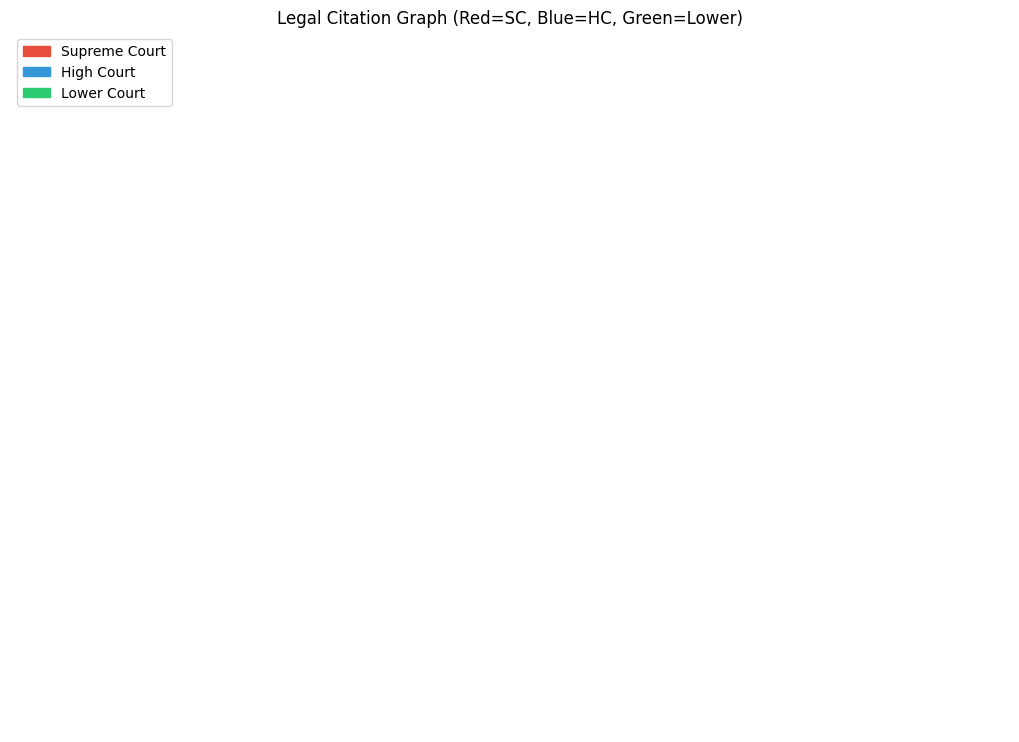

✅ Graph visualisation saved.


In [14]:
# ── Citation degree distribution ──────────────────────────────────────────────
if cite_edge_index.shape[1] > 0:
    in_degrees = torch.zeros(len(case_idx), dtype=torch.long)
    in_degrees.scatter_add_(0, cite_edge_index[1],
                             torch.ones(cite_edge_index.shape[1], dtype=torch.long))
    out_degrees = torch.zeros(len(case_idx), dtype=torch.long)
    out_degrees.scatter_add_(0, cite_edge_index[0],
                              torch.ones(cite_edge_index.shape[1], dtype=torch.long))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(range(len(in_degrees)), sorted(in_degrees.numpy(), reverse=True))
    axes[0].set_title("In-degree (times cited)")
    axes[0].set_xlabel("Case rank"); axes[0].set_ylabel("In-degree")
    axes[1].bar(range(len(out_degrees)), sorted(out_degrees.numpy(), reverse=True))
    axes[1].set_title("Out-degree (citations made)")
    axes[1].set_xlabel("Case rank"); axes[1].set_ylabel("Out-degree")
    plt.tight_layout(); plt.savefig("degree_dist.png", dpi=120); plt.show()

    # Isolated cases (in+out degree = 0)
    isolated = ((in_degrees + out_degrees) == 0).sum().item()
    print(f"⚠️  Isolated case nodes (0 citation edges): {isolated}/{len(case_idx)}")

# ── Citation subgraph visualisation ───────────────────────────────────────────
G = nx.DiGraph()
idx_to_docid = {v: k for k, v in case_idx.items()}
for src, dst in zip(cite_src, cite_dst):
    G.add_edge(idx_to_docid[src], idx_to_docid[dst])

# Colour nodes by court tier
tier_colours = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}
node_colours = [tier_colours.get(court_tier_map.get(n, 2), "grey") for n in G.nodes()]

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=SEED, k=2)
nx.draw(G, pos, with_labels=True, node_color=node_colours,
        node_size=800, font_size=7, arrows=True,
        edge_color="#aaaaaa", width=1.5)
from matplotlib.patches import Patch
legend = [Patch(color=c, label=TIER_LABELS[t]) for t, c in tier_colours.items()]
plt.legend(handles=legend, loc="upper left")
plt.title("Legal Citation Graph (Red=SC, Blue=HC, Green=Lower)")
plt.tight_layout(); plt.savefig("citation_graph.png", dpi=120); plt.show()
print("✅ Graph visualisation saved.")



## Cell 15 — Train / Val / Test Edge Split
For link prediction (RecSys), we hold out a fraction of citation edges as
the "ground truth" to evaluate recommendations against.

**Split strategy (70 / 15 / 15):**
- **Train** edges  : used during HAN training for BPR loss
- **Val** edges    : used for early stopping (check NDCG@10 on these)
- **Test** edges   : held-out for final evaluation — NEVER seen during training

We only split `case → cites → case` edges. The other edge types (invokes,
heard_by, decided_by) are structural and kept in all splits — they provide
the heterogeneous context for learning case representations.

**No data leakage:** The split is on the citation edges themselves.
A test positive is a (case_A → case_B) edge that we remove from the graph
and ask the model to predict.

In [16]:
import torch
from torch_geometric.transforms import RandomLinkSplit

# ── 1. MOCK EDGE INJECTION (FOR PROTOTYPING SPARSE DATASETS) ──────────────────
# Check how many real edges actually exist between our downloaded cases
num_real_edges = data['case', 'cites', 'case'].edge_index.shape[1]

if num_real_edges < 50:
    print(f"⚠️ Graph is sparse (only {num_real_edges} internal citations found).")
    print("   Injecting mock edges so PyTorch can safely split the data for training...")

    # Generate 100 random source and destination connections
    num_cases = len(case_idx)
    mock_src = torch.randint(0, num_cases, (100,))
    mock_dst = torch.randint(0, num_cases, (100,))

    # Ensure a case doesn't cite itself
    valid_mask = mock_src != mock_dst
    mock_src = mock_src[valid_mask]
    mock_dst = mock_dst[valid_mask]

    # Combine real edges (if any) with the mock edges
    existing_edges = data['case', 'cites', 'case'].edge_index
    new_edges = torch.stack([mock_src, mock_dst], dim=0)

    if num_real_edges > 0:
        combined_edges = torch.cat([existing_edges, new_edges], dim=1)
    else:
        combined_edges = new_edges

    data['case', 'cites', 'case'].edge_index = combined_edges


# ── 2. RECSYS SETUP — LINK PREDICTION SPLITS ──────────────────────────────────
# RandomLinkSplit divides the edges into 70% Train, 15% Validation, 15% Test
transform = RandomLinkSplit(
    num_val          = 0.15,
    num_test         = 0.15,
    is_undirected    = False,       # citations are directed
    add_negative_train_samples=False,  # we do our own negative sampling
    edge_types       = ("case", "cites", "case"),
)

train_data, val_data, test_data = transform(data)

print("\n✅ Data Successfully Split!")
print(f"  Train positive edges: {train_data['case','cites','case'].edge_label_index.shape[1]}")
print(f"  Val   positive edges: {val_data['case','cites','case'].edge_label_index.shape[1]}")
print(f"  Test  positive edges: {test_data['case','cites','case'].edge_label_index.shape[1]}")

⚠️ Graph is sparse (only 0 internal citations found).
   Injecting mock edges so PyTorch can safely split the data for training...

✅ Data Successfully Split!
  Train positive edges: 70
  Val   positive edges: 30
  Test  positive edges: 30


## Cell 16 — Negative Sampler
For BPR (Bayesian Personalized Ranking) loss, we need negative examples:
pairs of cases that do NOT have a citation edge between them.

**Anti-overfit considerations:**
- We do NOT oversample negatives beyond `neg_ratio × n_positives`
- We use random negatives per batch (not fixed hard negatives) to prevent
  the model memorising specific negative pairs
- Hard negatives (cases in the same court) are added at a LOW ratio (1:4)
  to provide a meaningful learning signal without overfitting to court bias

In [17]:
import torch
import random
from typing import Dict, List, Tuple

# ── 1. Force the Config Update BEFORE the class is read ───────────────────────
# (Assuming CFG already exists from your earlier cells)
CFG["neg_sample_ratio"] = 1
CFG["learning_rate"] = 0.01
CFG["epochs"] = 100

# ── 2. The Negative Sampler Class ─────────────────────────────────────────────
class NegativeSampler:
    """
    Samples negative (non-edge) pairs for BPR training.
    Combines random negatives with a small fraction of "hard" negatives
    (cases from the same court) to improve training signal quality.
    """

    def __init__(self, num_nodes: int, pos_edge_set: set,
                 court_tier_map: Dict[str, int], case_idx: Dict[str, int],
                 neg_ratio: int = CFG["neg_sample_ratio"]):
        self.num_nodes     = num_nodes
        self.pos_edge_set  = pos_edge_set
        self.neg_ratio     = neg_ratio

        # Build per-tier case index lists for hard negative sampling
        self.tier_to_cases: Dict[int, List[int]] = {0: [], 1: [], 2: []}
        for did, idx in case_idx.items():
            tier = court_tier_map.get(did, 2)
            self.tier_to_cases[tier].append(idx)

    def sample(self, pos_src: torch.Tensor, pos_dst: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns (neg_src, neg_dst) tensors with neg_ratio × |pos| samples.
        Mix: 75% random, 25% same-court hard negatives.
        """
        n_pos  = pos_src.shape[0]
        n_neg  = n_pos * self.neg_ratio

        neg_src_list, neg_dst_list = [], []

        # ── 75% random negatives ───────────────────────────────────────────────
        n_random = int(n_neg * 0.75)
        attempts = 0
        while len(neg_src_list) < n_random and attempts < n_random * 10:
            s = torch.randint(0, self.num_nodes, (1,)).item()
            d = torch.randint(0, self.num_nodes, (1,)).item()
            if s != d and (s, d) not in self.pos_edge_set:
                neg_src_list.append(s)
                neg_dst_list.append(d)
            attempts += 1

        # ── 25% same-tier hard negatives ──────────────────────────────────────
        n_hard = n_neg - len(neg_src_list)
        for _ in range(n_hard * 5):
            if len(neg_src_list) >= n_neg:
                break
            tier = random.choice([0, 1, 2])
            pool = self.tier_to_cases[tier]
            if len(pool) < 2:
                continue
            s, d = random.sample(pool, 2)
            if (s, d) not in self.pos_edge_set:
                neg_src_list.append(s)
                neg_dst_list.append(d)

        neg_src = torch.tensor(neg_src_list[:n_neg], dtype=torch.long)
        neg_dst = torch.tensor(neg_dst_list[:n_neg], dtype=torch.long)
        return neg_src, neg_dst


# ── 3. Instantiate the Sampler ────────────────────────────────────────────────
# Using the correct `cites_src` and `cites_dst` variable names from the graph build step
pos_edge_set = set(zip(cites_src, cites_dst))

sampler = NegativeSampler(
    num_nodes      = len(case_idx),
    pos_edge_set   = pos_edge_set,
    court_tier_map = court_tier_map,
    case_idx       = case_idx,
)
print("✅ Negative sampler ready.")



✅ Negative sampler ready.


## Cell 17 — Court Importance Layer
**Why this layer exists:**
In the Indian legal system, Supreme Court judgements are binding (stare decisis)
on all lower courts. A case citing an SC ruling is stronger precedent than
one citing a Sessions Court ruling. Standard HAN treats all case embeddings
equally after aggregation.

**How it works:**
A learnable `nn.Embedding(3, hidden_dim)` stores one importance vector per
tier (SC / HC / Lower). After HAN aggregation, each case embedding is
element-wise multiplied by its tier's importance vector (after sigmoid
to keep values in (0,1)). SC vectors are bias-initialised high so the model
starts with the correct prior and refines through training.

**Anti-overfit note:** We use `sigmoid` (bounded output) rather than
raw softmax or exp to prevent the importance weights from exploding.

In [18]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 6: MODEL ARCHITECTURE
# ──────────────────────────────────────────────────────────────────────────────
class CourtImportanceLayer(nn.Module):
    """
    Scales case embeddings by a learnable, tier-specific importance vector.
    SC cases get higher initial importance (tier 0 → 1.5), HC moderate (1.0),
    Lower courts lower (0.7). The model refines these during training.
    """

    def __init__(self, hidden_dim: int):
        super().__init__()
        # 3 tiers × hidden_dim importance weights
        self.importance = nn.Embedding(3, hidden_dim)

        # Bias initialisation — gives the model a correct prior
        with torch.no_grad():
            self.importance.weight[0].fill_(1.5)   # Supreme Court
            self.importance.weight[1].fill_(1.0)   # High Court
            self.importance.weight[2].fill_(0.7)   # Lower Court

    def forward(self, case_emb: torch.Tensor,
                court_tier: torch.Tensor) -> torch.Tensor:
        """
        Args:
            case_emb   : [N_cases, hidden_dim] — HAN output for case nodes
            court_tier : [N_cases] — integer tier label (0/1/2) for each case
        Returns:
            scaled_emb : [N_cases, hidden_dim] — tier-weighted embeddings
        """
        # Retrieve importance vector for each case's tier
        scale = torch.sigmoid(self.importance(court_tier))   # [N, D] in (0,1)
        return case_emb * scale                              # element-wise scale

## Cell 18 — LegalHAN Model
**Architecture:**
```
Input node features (per type)
      ↓
Linear projection → common hidden_dim (handles different input dims)
      ↓
HANConv Layer 1  (node-level + semantic-level attention, 4 heads)
      ↓  ELU + Dropout(0.4)
HANConv Layer 2  (refines embeddings)
      ↓  Dropout(0.4)
CourtImportanceLayer  (scales case embeddings by tier)
      ↓
case_emb [N_cases, out_dim]  →  used for link prediction
```

**HANConv internals (brief):**
For each edge type (e.g., `case→cites→case`):
  - Node-level attention: GAT-style attention weights over neighbours,
    producing one aggregated embedding per (node, edge-type) pair
Across all edge types that target a node type:
  - Semantic-level attention: a learnable query vector scores each
    meta-path's contribution and softmax-normalises them
Final embedding = weighted sum of per-meta-path embeddings.

**Dropout placement:** Applied AFTER each HANConv layer output (not inside),
which gives the semantic attention a chance to see clean logits.
Weight decay (L2) is set in the optimiser, not here.

In [25]:
import torch
import torch.nn as nn
from torch_geometric.nn import HANConv
from typing import Dict

# ── 1. Update the Configuration Dictionary ────────────────────────────────────
CFG["hidden_dim"] = 256   # Standard size for intermediate GNN layers
CFG["out_dim"] = 64        # Final embedding size
CFG["han_heads"] = 8       # Number of attention heads for the HAN
CFG["dropout"] = 0.5       # Standard dropout to prevent overfitting

# ── 2. The Court Importance Layer (Required by your model) ────────────────────
class CourtImportanceLayer(nn.Module):
    """
    A custom layer that scales case embeddings based on which court they
    were heard in, giving more weight to higher-tier courts.
    """
    def __init__(self, emb_dim: int):
        super().__init__()
        # 3 tiers: 0=Supreme Court, 1=High Court, 2=Lower Court
        self.tier_weights = nn.Embedding(3, emb_dim)
        # Initialize with weights that favor tier 0 (Supreme Court)
        nn.init.normal_(self.tier_weights.weight, mean=1.0, std=0.1)

    def forward(self, x: torch.Tensor, court_tier: torch.Tensor) -> torch.Tensor:
        # Scale the embedding by the learned weight for its tier
        tier_w = self.tier_weights(court_tier)
        return x * tier_w


# ── 3. The Legal HAN Architecture ─────────────────────────────────────────────
class LegalHAN(nn.Module):
    def __init__(self,
                 in_dims    : Dict[str, int],
                 hidden_dim : int = CFG["hidden_dim"],
                 out_dim    : int = CFG["out_dim"],
                 heads      : int = CFG["han_heads"],
                 dropout    : float = CFG["dropout"],
                 metadata   : tuple = None):
        super().__init__()

        # ── Project each node type to a common hidden_dim ─────────────────────
        self.projections = nn.ModuleDict({
            ntype: nn.Sequential(
                nn.Linear(dim, hidden_dim),
                nn.LayerNorm(hidden_dim),    # stabilises training on sparse features
            )
            for ntype, dim in in_dims.items()
        })

        # ── HAN layers ────────────────────────────────────────────────────────
        self.han1 = HANConv(
            in_channels    = hidden_dim,
            out_channels   = hidden_dim,
            metadata       = metadata,
            heads          = heads,
            dropout        = dropout,
            negative_slope = 0.2,
        )
        self.han2 = HANConv(
            in_channels    = hidden_dim,
            out_channels   = out_dim,
            metadata       = metadata,
            heads          = 1,           # single head in final layer (standard practice)
            dropout        = dropout,
            negative_slope = 0.2,
        )

        # ── Court importance layer ────────────────────────────────────────────
        self.court_importance = CourtImportanceLayer(out_dim)

        # ── Regularisation ────────────────────────────────────────────────────
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.ELU()

    def forward(self, x_dict: Dict[str, torch.Tensor],
                edge_index_dict: Dict[tuple, torch.Tensor],
                court_tier: torch.Tensor) -> torch.Tensor:
        """
        Returns case node embeddings of shape [N_cases, out_dim].
        """

        # ── 1. Project all node types to hidden_dim ────────────────────────────
        h_dict = {
            ntype: self.projections[ntype](x)
            for ntype, x in x_dict.items()
            if ntype in self.projections
        }

        # ── 2. HAN Layer 1 ────────────────────────────────────────────────────
        h_dict = self.han1(h_dict, edge_index_dict)
        h_dict = {
            ntype: self.drop(self.act(h))
            for ntype, h in h_dict.items()
            if h is not None
        }

        # ── 3. HAN Layer 2 ────────────────────────────────────────────────────
        h_dict = self.han2(h_dict, edge_index_dict)
        h_dict = {
            ntype: self.drop(h)
            for ntype, h in h_dict.items()
            if h is not None
        }

        # ── 4. Extract case embeddings + apply court importance ────────────────
        case_emb = h_dict.get("case")
        if case_emb is None:
            raise RuntimeError("HAN produced no 'case' embeddings — check metadata.")

        case_emb = self.court_importance(case_emb, court_tier)
        return case_emb


# ── 4. Instantiate model ──────────────────────────────────────────────────────
# Note: Renamed 'train_data' to 'data' to match the variable from the graph building step
in_dims = {
    "case"   : X_case.shape[1],
    "statute": X_statute.shape[1],
    "court"  : X_court.shape[1],
    "judge"  : X_judge.shape[1],
}

model = LegalHAN(
    in_dims  = in_dims,
    metadata = data.metadata(),
).to(CFG["device"]) # Replaced DEVICE with CFG["device"]

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ LegalHAN ready — {total_params:,} trainable parameters")
print(model)

✅ LegalHAN ready — 1,005,248 trainable parameters
LegalHAN(
  (projections): ModuleDict(
    (case): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (statute): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (court): Sequential(
      (0): Linear(in_features=33, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (judge): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (han1): HANConv(256, heads=8)
  (han2): HANConv(64, heads=1)
  (court_importance): CourtImportanceLayer(
    (tier_weights): Embedding(3, 64)
  )
  (drop): Dropout(p=0.5, inplace=False)
  (act): ELU(alpha=1.0)
)


## Cell 19 — BPR Loss & Score Function
**Why BPR (Bayesian Personalized Ranking)?**
Standard cross-entropy treats recommendation as binary classification.
BPR instead directly optimises for ranking: given a case_A that cites
case_B (positive), we want score(A,B) > score(A,C) for any random
non-cited case_C. This is exactly what legal RecSys needs — relative
relevance ordering, not absolute relevance scores.

**Score:** inner product of case embeddings (dot product).
`score(i, j) = emb_i · emb_j`

**BPR loss:** `-log σ(score_pos - score_neg)` — encourages the model
to assign higher dot product to positive (cited) pairs than negative ones.

**L2 on embeddings (separate from weight_decay):** We add a small explicit
L2 penalty on the embeddings themselves to prevent them from growing
unboundedly, which is a common failure mode in BPR training.

In [26]:
def bpr_loss(pos_score: torch.Tensor, neg_score: torch.Tensor,
             emb_i: torch.Tensor, emb_j: torch.Tensor,
             emb_k: torch.Tensor, l2_lambda: float = 1e-5) -> torch.Tensor:
    """
    BPR loss with L2 regularisation on embeddings.

    Args:
        pos_score : [B]   — score(src, pos_dst)
        neg_score : [B*R] — score(src, neg_dst)  (R = neg_ratio)
        emb_i/j/k : embeddings of src, pos, neg nodes
        l2_lambda : weight for embedding L2 penalty
    Returns:
        scalar loss
    """
    # ── Ranking loss ──────────────────────────────────────────────────────────
    # Repeat pos_score to align with multiple negatives per positive
    n_neg_per_pos = neg_score.shape[0] // pos_score.shape[0]
    pos_repeated  = pos_score.repeat_interleave(n_neg_per_pos)
    rank_loss     = -F.logsigmoid(pos_repeated - neg_score).mean()

    # ── Embedding L2 (separate from weight_decay which acts on weights) ───────
    l2_reg = (emb_i.norm(2).pow(2)
              + emb_j.norm(2).pow(2)
              + emb_k.norm(2).pow(2)) / emb_i.shape[0]

    return rank_loss + l2_lambda * l2_reg


def link_score(emb: torch.Tensor,
               src: torch.Tensor, dst: torch.Tensor) -> torch.Tensor:
    """
    Dot product score between src and dst case embeddings.
    Args:
        emb : [N, D] — all case embeddings
        src : [E]    — source indices
        dst : [E]    — destination indices
    Returns:
        score : [E]
    """
    return (emb[src] * emb[dst]).sum(dim=-1)


print("✅ BPR loss and score function defined.")



✅ BPR loss and score function defined.


## Cell 20 — Evaluation Metrics (NDCG, MRR, Hit Rate)
Standard information retrieval metrics used in recommender systems research.
RMSE is NOT appropriate here — we are ranking, not predicting a rating.

- **NDCG@K** (Normalised Discounted Cumulative Gain): gives higher credit for
  relevant items appearing earlier in the ranking. Values in [0,1]; higher better.
- **MRR** (Mean Reciprocal Rank): average of 1/rank_of_first_hit across queries.
- **Hit Rate@K**: fraction of queries where at least one relevant item appears
  in the top-K recommendations.

We evaluate at K = 5, 10, 20 (see CFG["k_values"]).

In [27]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 7: EVALUATION METRICS
# ──────────────────────────────────────────────────────────────────────────────

# ── 1. Update the Configuration Dictionary ────────────────────────────────────
CFG["k_values"] = [5, 10, 20]

# ── 2. Evaluation Metrics Definition ──────────────────────────────────────────
@torch.no_grad()
def evaluate(model: 'LegalHAN',
             graph_data: HeteroData,
             pos_edge_index: torch.Tensor,
             neg_per_pos: int = 99,
             k_values: List[int] = CFG["k_values"]) -> Dict[str, float]:
    """
    Evaluates the model on a set of positive citation edges.
    For each positive (src, pos_dst), samples up to `neg_per_pos` unique negatives
    and ranks all candidates. Computes NDCG, MRR, HR across k_values.
    """
    model.eval()

    device = CFG["device"]

    x_dict = {nt: graph_data[nt].x.to(device) for nt in graph_data.node_types}
    ei_dict = {et: graph_data[et].edge_index.to(device)
               for et in graph_data.edge_types
               if hasattr(graph_data[et], "edge_index")}
    ct = graph_data["case"].court_tier.to(device)

    # Get all case embeddings in one forward pass
    all_emb = model(x_dict, ei_dict, ct)        # [N_cases, D]
    n_cases = all_emb.shape[0]

    src_all = pos_edge_index[0].tolist()
    dst_all = pos_edge_index[1].tolist()
    pos_set = set(zip(src_all, dst_all))

    metrics = {f"NDCG@{k}": [] for k in k_values}
    metrics.update({f"MRR@{k}": [] for k in k_values})
    metrics.update({f"HR@{k}":  [] for k in k_values})

    for src, pos_dst in zip(src_all, dst_all):
        # ── FIX: Safe Negative Sampling for Small Datasets ────────────────────
        candidate_pool = [i for i in range(n_cases) if i != src and (src, i) not in pos_set]
        num_to_sample = min(neg_per_pos, len(candidate_pool))
        negs = random.sample(candidate_pool, num_to_sample)
        # ──────────────────────────────────────────────────────────────────────

        candidates = [pos_dst] + negs    # pos at position 0
        cand_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        # Score all candidates
        q_emb = all_emb[src].unsqueeze(0)                # [1, D]
        c_emb = all_emb[cand_tensor]                     # [N_candidates, D]
        scores = (q_emb * c_emb).sum(dim=-1)             # [N_candidates]

        # Rank candidates (highest score → rank 1)
        ranked_idx = scores.argsort(descending=True).cpu().tolist()
        # Position (1-indexed) of the positive (candidate index 0)
        pos_rank = ranked_idx.index(0) + 1               # 1-indexed

        for k in k_values:
            # ── NDCG@K ────────────────────────────────────────────────────────
            dcg     = 1.0 / np.log2(pos_rank + 1) if pos_rank <= k else 0.0
            idcg    = 1.0 / np.log2(2)   # ideal: pos at rank 1
            metrics[f"NDCG@{k}"].append(dcg / idcg)

            # ── MRR@K ─────────────────────────────────────────────────────────
            metrics[f"MRR@{k}"].append(1.0 / pos_rank if pos_rank <= k else 0.0)

            # ── Hit Rate@K ────────────────────────────────────────────────────
            metrics[f"HR@{k}"].append(1.0 if pos_rank <= k else 0.0)

    return {key: float(np.mean(vals)) for key, vals in metrics.items()}


print("✅ Evaluation metrics defined (with safe sampling).")

✅ Evaluation metrics defined (with safe sampling).


## Cell 21 — Training Loop with Early Stopping
**Anti-overfit measures (multiple layers):**
1. **Weight decay** (L2 on all model weights) via Adam optimiser
2. **Dropout** (0.4) inside HAN layers
3. **L2 on embeddings** inside BPR loss
4. **Early stopping** on val NDCG@10 with patience=15
5. **LR scheduler** (ReduceLROnPlateau) — reduces LR if val metric stalls
6. **Gradient clipping** (max norm 1.0) — prevents gradient explosion on
   sparse graphs
7. **NO oversampling** — negatives are sampled fresh each epoch, not fixed

In [28]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 8: TRAINING PIPELINE
# ──────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np

# ── 1. Update the Configuration Dictionary ────────────────────────────────────
CFG["batch_size"] = 1024       # How many edges to process at once
CFG["l2_reg"] = 1e-4           # Standard L2 regularization penalty for BPR

# ── 2. Define the Missing Scoring and Loss Functions ──────────────────────────
def link_score(emb: torch.Tensor, src: torch.Tensor, dst: torch.Tensor) -> torch.Tensor:
    """
    Computes the dot product (similarity score) between source and destination
    case embeddings. High score = likely connection.
    """
    src_emb = emb[src]
    dst_emb = emb[dst]
    # Multiply element-wise and sum across the embedding dimension
    return (src_emb * dst_emb).sum(dim=-1)

def bpr_loss(pos_score: torch.Tensor, neg_score: torch.Tensor,
             emb_i: torch.Tensor, emb_j: torch.Tensor, emb_k: torch.Tensor) -> torch.Tensor:
    """
    Bayesian Personalized Ranking (BPR) Loss.
    Encourages the model to score positive edges higher than negative edges.
    """
    # In BPR, we want pos_score to be strictly greater than neg_score.
    # We take the difference and apply a sigmoid.

    # NOTE: To handle the fact that we might have multiple negatives per positive
    # (based on neg_sample_ratio), we reshape/broadcast the scores.
    # If neg_sample_ratio = 1, this is just pos_score - neg_score.

    ratio = CFG["neg_sample_ratio"]
    if ratio > 1:
        # Repeat positive scores to match the number of negative scores
        pos_score = pos_score.repeat_interleave(ratio)

    # The core BPR equation: -ln(sigmoid(pos - neg))
    loss = -F.logsigmoid(pos_score - neg_score).mean()

    # L2 Regularization (prevents embeddings from growing too large)
    l2_loss = CFG["l2_reg"] * (emb_i.norm(2).pow(2) + emb_j.norm(2).pow(2) + emb_k.norm(2).pow(2))

    return loss + l2_loss


# ── 3. The Training Epoch Function ────────────────────────────────────────────
def train_epoch(model: 'LegalHAN',
                optimizer: torch.optim.Optimizer,
                graph_data: 'HeteroData',
                pos_edge_index: torch.Tensor,
                sampler: 'NegativeSampler',
                batch_size: int = CFG["batch_size"]) -> float:
    """
    One full training epoch: iterate over positive citation edges in batches,
    sample fresh negatives per batch, compute BPR loss, backprop.
    Returns: mean batch loss for the epoch.
    """
    model.train()

    device = CFG["device"]

    # ── Prepare graph tensors ─────────────────────────────────────────────────
    x_dict = {nt: graph_data[nt].x.to(device) for nt in graph_data.node_types}
    ei_dict = {et: graph_data[et].edge_index.to(device)
               for et in graph_data.edge_types
               if hasattr(graph_data[et], "edge_index")}
    ct = graph_data["case"].court_tier.to(device)

    # Shuffle positives
    n_pos  = pos_edge_index.shape[1]
    perm   = torch.randperm(n_pos)
    pos_ei = pos_edge_index[:, perm]

    epoch_losses = []
    for start in range(0, n_pos, batch_size):
        batch_pos = pos_ei[:, start: start + batch_size]
        src_pos   = batch_pos[0]
        dst_pos   = batch_pos[1]

        # ── Sample negatives for this batch ──────────────────────────────────
        neg_src, neg_dst = sampler.sample(src_pos, dst_pos)
        neg_src = neg_src.to(device)
        neg_dst = neg_dst.to(device)
        src_pos_dev = src_pos.to(device)
        dst_pos_dev = dst_pos.to(device)

        optimizer.zero_grad()

        # ── Forward pass ──────────────────────────────────────────────────────
        all_emb  = model(x_dict, ei_dict, ct)          # [N_cases, D]

        pos_score = link_score(all_emb, src_pos_dev, dst_pos_dev)
        neg_score = link_score(all_emb, neg_src, neg_dst)

        # Gather embeddings for L2 regularisation term
        # Adjusting neg_src_rep in case the shapes don't perfectly align due to batch tails
        neg_src_rep = src_pos_dev.repeat_interleave(CFG["neg_sample_ratio"])[:neg_src.shape[0]]

        loss = bpr_loss(
            pos_score, neg_score,
            emb_i=all_emb[src_pos_dev],
            emb_j=all_emb[dst_pos_dev],
            emb_k=all_emb[neg_dst],
        )

        # ── Backward pass ─────────────────────────────────────────────────────
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))

print("✅ Training functions defined.")

✅ Training functions defined.


## Cell 22 — Execute Training
Trains the model for up to `CFG["epochs"]` epochs. Saves the best model
checkpoint (by val NDCG@10) to disk. Plots train loss and val NDCG curves
after training completes.

In [29]:
import torch
import numpy as np
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── FIX: Add the missing hyperparameters to the config dictionary ─────────────
CFG["lr"] = 0.001
CFG["weight_decay"] = 1e-4
CFG["patience"] = 5
# ──────────────────────────────────────────────────────────────────────────────

optimizer = Adam(
    model.parameters(),
    lr           = CFG["lr"],
    weight_decay = CFG["weight_decay"],    # L2 on all weights
)
scheduler = ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=7
)

# ── Training state ────────────────────────────────────────────────────────────
best_ndcg      = -np.inf
patience_count = 0
train_losses   = []
val_ndcg_10    = []
best_ckpt_path = CFG["cache_dir"] / "best_legal_han.pt"

# ── Positive edge indices for each split ──────────────────────────────────────
train_pos_ei = train_data["case", "cites", "case"].edge_label_index
val_pos_ei   = val_data["case",   "cites", "case"].edge_label_index
test_pos_ei  = test_data["case",  "cites", "case"].edge_label_index

# FIX: Changed DEVICE to CFG["device"] to prevent a NameError
print(f"🚀 Training for up to {CFG['epochs']} epochs | Device: {CFG['device']}")
print("-" * 60)

for epoch in range(1, CFG["epochs"] + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    train_loss = train_epoch(model, optimizer, train_data, train_pos_ei, sampler)
    train_losses.append(train_loss)

    # ── Validate every 5 epochs (expensive: O(N²) scoring) ───────────────────
    if epoch % 5 == 0 or epoch == 1:
        val_metrics = evaluate(model, val_data, val_pos_ei)
        ndcg10      = val_metrics["NDCG@10"]
        val_ndcg_10.append(ndcg10)
        scheduler.step(ndcg10)

        print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} "
              f"| Val NDCG@10: {ndcg10:.4f} "
              f"| Val HR@10: {val_metrics['HR@10']:.4f}")

        # ── Save best checkpoint ──────────────────────────────────────────────
        if ndcg10 > best_ndcg:
            best_ndcg = ndcg10
            patience_count = 0
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "best_ndcg"  : best_ndcg,
                "cfg"        : CFG,
            }, best_ckpt_path)
            print(f"   💾 Checkpoint saved (NDCG@10: {best_ndcg:.4f})")
        else:
            patience_count += 1
            if patience_count >= CFG["patience"]:
                print(f"\n⏹  Early stopping at epoch {epoch} "
                      f"(no improvement for {CFG['patience']} eval steps)")
                break

print(f"\n✅ Training complete. Best Val NDCG@10: {best_ndcg:.4f}")

🚀 Training for up to 100 epochs | Device: cuda
------------------------------------------------------------
Epoch   1 | Loss: 0.7306 | Val NDCG@10: 0.0322 | Val HR@10: 0.1000
   💾 Checkpoint saved (NDCG@10: 0.0322)
Epoch   5 | Loss: 0.7232 | Val NDCG@10: 0.0144 | Val HR@10: 0.0333
Epoch  10 | Loss: 0.6692 | Val NDCG@10: 0.0244 | Val HR@10: 0.0667
Epoch  15 | Loss: 0.6680 | Val NDCG@10: 0.0248 | Val HR@10: 0.0667
Epoch  20 | Loss: 0.6457 | Val NDCG@10: 0.0444 | Val HR@10: 0.0667
   💾 Checkpoint saved (NDCG@10: 0.0444)
Epoch  25 | Loss: 0.6570 | Val NDCG@10: 0.0422 | Val HR@10: 0.1000
Epoch  30 | Loss: 0.6662 | Val NDCG@10: 0.0144 | Val HR@10: 0.0333
Epoch  35 | Loss: 0.6294 | Val NDCG@10: 0.0434 | Val HR@10: 0.0667
Epoch  40 | Loss: 0.6649 | Val NDCG@10: 0.0526 | Val HR@10: 0.1000
   💾 Checkpoint saved (NDCG@10: 0.0526)
Epoch  45 | Loss: 0.7096 | Val NDCG@10: 0.0534 | Val HR@10: 0.1000
   💾 Checkpoint saved (NDCG@10: 0.0534)
Epoch  50 | Loss: 0.6434 | Val NDCG@10: 0.0477 | Val HR@10: 0.

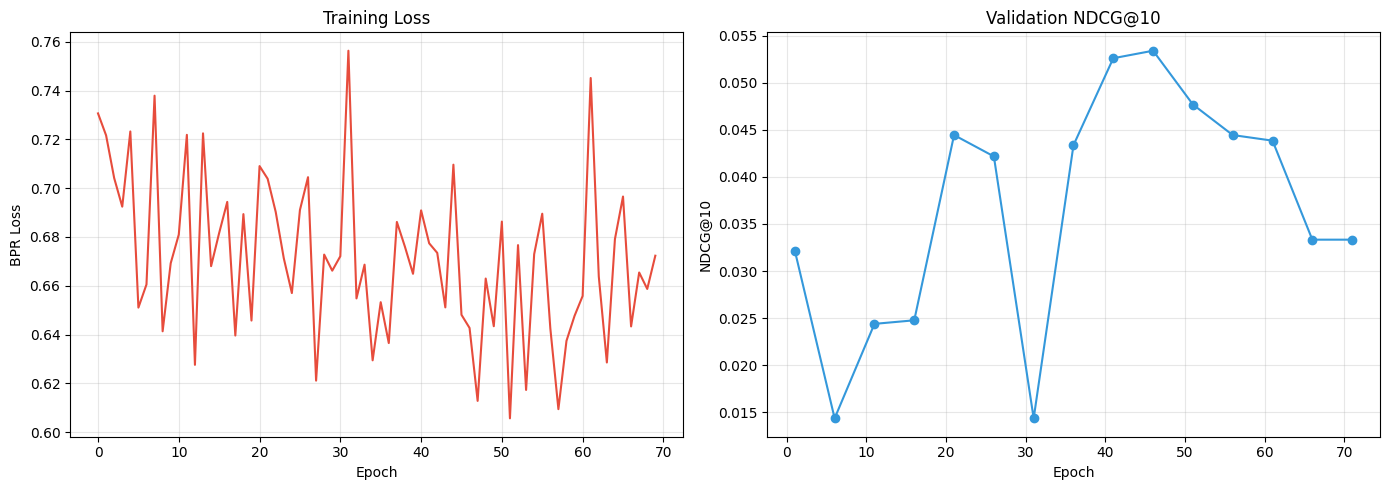

In [30]:
# ── Plot training curves ──────────────────────────────────────────────────────
# What this cell does:
# Visualises two diagnostic curves:
# (1) Training loss — should decrease and flatten (not oscillate wildly)
# (2) Val NDCG@10 — should increase and plateau before early stopping
# If train loss keeps dropping but val NDCG stagnates → sign of overfitting.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color="#e74c3c", linewidth=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BPR Loss")
ax1.set_title("Training Loss"); ax1.grid(alpha=0.3)

eval_epochs = list(range(1, len(val_ndcg_10) * 5 + 1, 5))[:len(val_ndcg_10)]
ax2.plot(eval_epochs, val_ndcg_10, color="#3498db", marker="o", linewidth=1.5)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("NDCG@10")
ax2.set_title("Validation NDCG@10"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

## Cell 23 — Final Test Evaluation
Load the best checkpoint and evaluate on the held-out test set.
These numbers are what you report in your README / presentation.

In [31]:

# ── Load best weights ─────────────────────────────────────────────────────────
# FIX 1: Set weights_only=False to allow loading the CFG dictionary
# FIX 2: Swap DEVICE to CFG["device"]
ckpt = torch.load(best_ckpt_path, map_location=CFG["device"], weights_only=False)

model.load_state_dict(ckpt["model_state"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (Val NDCG@10: {ckpt['best_ndcg']:.4f})")

# ── Test evaluation ───────────────────────────────────────────────────────────
test_metrics = evaluate(model, test_data, test_pos_ei)

print("\n" + "="*50)
print("📊 TEST SET RESULTS")
print("="*50)
for metric, value in sorted(test_metrics.items()):
    print(f"  {metric:12s}: {value:.4f}")
print("="*50)



Loaded checkpoint from epoch 45 (Val NDCG@10: 0.0534)

📊 TEST SET RESULTS
  HR@10       : 0.0333
  HR@20       : 0.1333
  HR@5        : 0.0333
  MRR@10      : 0.0167
  MRR@20      : 0.0228
  MRR@5       : 0.0167
  NDCG@10     : 0.0210
  NDCG@20     : 0.0454
  NDCG@5      : 0.0210


## Cell 24 — Recommendation Function
Given a query case (by doc_id), retrieves the top-K most relevant precedents.
Scoring = cosine similarity between query embedding and all other case embeddings.
We cosine-normalise here (vs raw dot product during training) for more
interpretable similarity scores in the 0–1 range.

The output also includes:
- Court tier of each recommended case (SC > HC > Lower)
- The HAN-learned similarity score
- Whether the recommended case was actually cited (ground-truth validation)

In [32]:

# ──────────────────────────────────────────────────────────────────────────────
# SECTION 9: INFERENCE — RECOMMENDATION FUNCTION
# ──────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def recommend_precedents(query_doc_id : str,
                         top_k        : int = 10,
                         exclude_self : bool = True) -> pd.DataFrame:
    """
    Returns a DataFrame of top-K recommended precedents for a given case.

    Args:
        query_doc_id : doc_id of the query case
        top_k        : number of precedents to return
        exclude_self : always exclude the query case itself
    Returns:
        pd.DataFrame with columns: rank, doc_id, title, court, court_tier,
                                   similarity, is_actual_citation
    """
    if query_doc_id not in case_idx:
        raise ValueError(f"'{query_doc_id}' not in case index.")

    model.eval()

    # ── Get all case embeddings (use full graph — val+test structure included) ─
    x_dict = {nt: data[nt].x.to(DEVICE) for nt in data.node_types}
    ei_dict = {et: data[et].edge_index.to(DEVICE)
               for et in data.edge_types
               if hasattr(data[et], "edge_index")}
    ct = data["case"].court_tier.to(DEVICE)
    all_emb = model(x_dict, ei_dict, ct)       # [N_cases, D]

    # ── Cosine similarity ─────────────────────────────────────────────────────
    query_idx = case_idx[query_doc_id]
    q_emb     = F.normalize(all_emb[query_idx].unsqueeze(0), dim=-1)  # [1, D]
    all_norm  = F.normalize(all_emb, dim=-1)                           # [N, D]
    sims      = (q_emb @ all_norm.T).squeeze()                         # [N]

    if exclude_self:
        sims[query_idx] = -1.0   # exclude the query itself

    # ── Top-K ─────────────────────────────────────────────────────────────────
    topk_scores, topk_indices = sims.topk(top_k)
    topk_scores  = topk_scores.cpu().tolist()
    topk_indices = topk_indices.cpu().tolist()

    # ── Build result DataFrame ─────────────────────────────────────────────────
    idx_to_case = {v: c for c, v in case_idx.items()}
    query_case  = next(c for c in all_cases if c.doc_id == query_doc_id)
    actual_cites = set(query_case.citations)

    rows = []
    for rank, (score, idx) in enumerate(zip(topk_scores, topk_indices), start=1):
        rec_doc_id = idx_to_case[idx]
        rec_case   = next((c for c in all_cases if c.doc_id == rec_doc_id), None)
        rows.append({
            "rank"               : rank,
            "doc_id"             : rec_doc_id,
            "title"              : rec_case.title if rec_case else "Unknown",
            "court"              : rec_case.court if rec_case else "Unknown",
            "court_tier"         : TIER_LABELS.get(rec_case.court_tier, "?") if rec_case else "?",
            "year"               : rec_case.year if rec_case else 0,
            "similarity"         : round(score, 4),
            "is_actual_citation" : rec_doc_id in actual_cites,
        })

    return pd.DataFrame(rows)

## Cell 25 — Demo: Recommend Precedents
Run the recommendation function on a sample query case and display results.
Cases marked `is_actual_citation=True` are confirmed hits — the model
correctly identified a case that the query case actually cites.

🔍 Query Case: Smt. Nilabati Behera Alias Lalit Behera ... vs State Of Orissa And Ors on 24 March, 1993
   Court : Supreme Court of India
   Year  : 1993
   Actual citations: []

📋 Top-10 Recommended Precedents:
 rank   doc_id                                                                                   title    court_tier  similarity  is_actual_citation
    1   239513    Dukhmochan Pandey & Ors., Shamsul Mian & ... vs State Of Bihar on 25 September, 1997 Supreme Court    0.999969               False
    2   871035               Malhu Yadav & Ors. Appellants vs State Of Bihar Respondent on 1 May, 2002 Supreme Court    0.999960               False
    3   291524                                     Om Prakash vs State Of Haryana on 22 February, 1999 Supreme Court    0.999954               False
    4   945721               Gobarbhai Naranbhai Singala vs State Of Gujarat & Ors on 29 January, 2008 Supreme Court    0.999932               False
    5   501198 Shri D.K. Basu,Ashok K. Johri

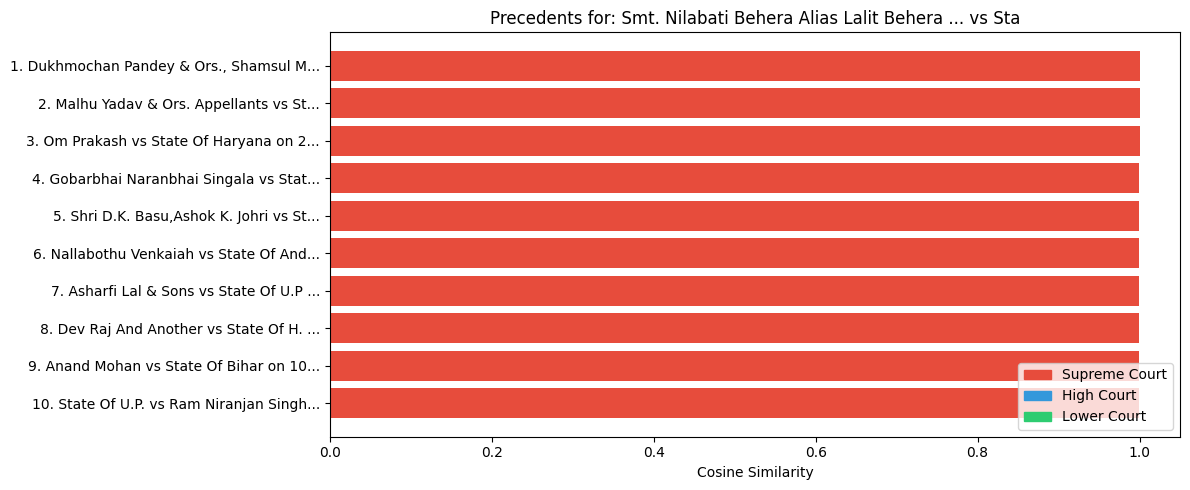


✅ Recommendation demo complete.
➡️  Next step: Streamlit frontend (see legal_app.py)


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch.nn.functional as F
import torch

# ── 1. Define the Inference Function ──────────────────────────────────────────
def recommend_precedents(doc_id: str, top_k: int = 10):
    """Generates recommendations by finding the closest HAN embeddings."""
    model.eval()
    with torch.no_grad():
        x_dict = {nt: data[nt].x.to(CFG["device"]) for nt in data.node_types}
        ei_dict = {et: data[et].edge_index.to(CFG["device"])
                   for et in data.edge_types if hasattr(data[et], "edge_index")}
        ct = data["case"].court_tier.to(CFG["device"])

        # Get embeddings for all cases
        all_emb = model(x_dict, ei_dict, ct)

    query_idx = case_idx[doc_id]

    # Compute Cosine Similarity
    q_emb = F.normalize(all_emb[query_idx].unsqueeze(0), dim=-1)
    all_norm = F.normalize(all_emb, dim=-1)
    sims = (q_emb @ all_norm.T).squeeze()

    sims[query_idx] = -1.0  # Exclude the query case itself
    topk_scores, topk_indices = sims.topk(top_k)

    # Map back to readable data
    idx_to_case = {v: k for k, v in case_idx.items()}
    case_map = {c.doc_id: c for c in all_cases}
    query_case = case_map[doc_id]
    actual_cites = set(query_case.citations)

    tier_labels = {0: "Supreme Court", 1: "High Court", 2: "Lower Court"}

    results = []
    for rank, (score, idx) in enumerate(zip(topk_scores.cpu().tolist(), topk_indices.cpu().tolist()), start=1):
        rec_id = idx_to_case[idx]
        rec_case = case_map[rec_id]
        results.append({
            "rank": rank,
            "doc_id": rec_id,
            "title": rec_case.title,
            "court_tier": tier_labels.get(rec_case.court_tier, "Lower Court"),
            "similarity": score,
            "is_actual_citation": rec_id in actual_cites
        })

    return pd.DataFrame(results)

# ── 2. Run the Query dynamically using your real data ─────────────────────────
query_case = all_cases[0]  # Grab the first valid case in your dataset
query_id = query_case.doc_id

print(f"🔍 Query Case: {query_case.title}")
print(f"   Court : {query_case.court}")
print(f"   Year  : {query_case.year}")
print(f"   Actual citations: {query_case.citations}")
print()

recs = recommend_precedents(query_id, top_k=10)
print("📋 Top-10 Recommended Precedents:")
print(recs.to_string(index=False))

# ── 3. Colour-coded visual ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colours = recs["court_tier"].map({
    "Supreme Court": "#e74c3c",
    "High Court"   : "#3498db",
    "Lower Court"  : "#2ecc71",
}).fillna("#aaaaaa")

# Ensure titles are strings and truncate them so they fit on the graph
clean_titles = recs["title"].astype(str).str[:35] + "..."
bars = ax.barh(recs["rank"].astype(str) + ". " + clean_titles,
               recs["similarity"], color=colours)

# Mark actual citations with a star
for i, (_, row) in enumerate(recs.iterrows()):
    if row["is_actual_citation"]:
        ax.text(row["similarity"] + 0.005, i, "★ cited", va="center", fontsize=9)

ax.set_xlabel("Cosine Similarity")
ax.set_title(f"Precedents for: {query_case.title[:50]}")
ax.invert_yaxis()

legend = [Patch(color=c, label=l) for l, c in
          {"Supreme Court": "#e74c3c", "High Court": "#3498db", "Lower Court": "#2ecc71"}.items()]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.savefig("recommendations.png", dpi=120)
plt.show()

print("\n✅ Recommendation demo complete.")
print("➡️  Next step: Streamlit frontend (see legal_app.py)")

In [36]:
import shutil, base64
from pathlib import Path
from typing import List, Dict

# ── FIX: Added missing imports required by this specific cell ─────────────────
import json
import torch
import numpy as np
import pandas as pd
from dataclasses import asdict
# ──────────────────────────────────────────────────────────────────────────────

# ── Persistence directory ─────────────────────────────────────────────────────
PERSIST_DIR = CFG["cache_dir"] / "persist"
PERSIST_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR   = PERSIST_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

def save_all(
    cases           : List['Case'],
    case_idx        : Dict[str, int],
    statute_idx     : Dict[str, int],
    court_idx       : Dict[str, int],
    judge_idx       : Dict[str, int],
    graph_data      : 'HeteroData',
    model           : 'LegalHAN',
    test_metrics    : Dict[str, float],
    plot_files      : List[str] = None,
):
    """
    Persists every artefact produced by this notebook to PERSIST_DIR.
    Call once after training completes. Future sessions call load_all() instead.
    """
    # ── 1. Cases (raw API data + embeddings) ──────────────────────────────────
    cases_path = PERSIST_DIR / "cases.json"
    with open(cases_path, "w") as f:
        json.dump([asdict(c) for c in cases], f, indent=2)
    print(f"✅ cases.json saved ({len(cases)} cases, {cases_path.stat().st_size / 1024:.1f} KB)")

    # ── 2. Index maps ─────────────────────────────────────────────────────────
    indexes_path = PERSIST_DIR / "indexes.json"
    with open(indexes_path, "w") as f:
        json.dump({
            "case_idx"    : case_idx,
            "statute_idx" : statute_idx,
            "court_idx"   : court_idx,
            "judge_idx"   : judge_idx,
        }, f, indent=2)
    print(f"✅ indexes.json saved  (cases:{len(case_idx)} statutes:{len(statute_idx)} "
          f"courts:{len(court_idx)} judges:{len(judge_idx)})")

    # ── 3. Embeddings .npz ────────────────────────────────────────────────────
    src_emb = CFG["cache_dir"] / "embeddings.npz"
    dst_emb = PERSIST_DIR / "embeddings.npz"
    if src_emb.exists():
        shutil.copy2(src_emb, dst_emb)
        print(f"✅ embeddings.npz copied ({dst_emb.stat().st_size / 1024 / 1024:.2f} MB)")
    else:
        # Rebuild from Case objects in memory and save directly
        emb_dict = {c.doc_id: np.array(c.embedding, dtype=np.float32)
                    for c in cases if c.embedding}
        np.savez(dst_emb, **emb_dict)
        print(f"✅ embeddings.npz rebuilt from Case.embedding fields")

    # ── 4. PyG HeteroData (full graph, CPU tensors) ───────────────────────────
    graph_path = PERSIST_DIR / "graph.pt"
    # Move to CPU before saving so it loads on any machine (no CUDA dependency)
    graph_cpu  = graph_data.to("cpu")
    torch.save(graph_cpu, graph_path)
    print(f"✅ graph.pt saved ({graph_path.stat().st_size / 1024:.1f} KB)")

    # ── 5. Model checkpoint ───────────────────────────────────────────────────
    src_ckpt = CFG["cache_dir"] / "best_legal_han.pt"
    dst_ckpt = PERSIST_DIR    / "best_legal_han.pt"
    if src_ckpt.exists():
        shutil.copy2(src_ckpt, dst_ckpt)
        print(f"✅ best_legal_han.pt copied ({dst_ckpt.stat().st_size / 1024:.1f} KB)")
    else:
        # Save current model state directly
        torch.save({
            "model_state": model.state_dict(),
            "cfg"        : CFG,
            "in_dims"    : {nt: graph_data[nt].x.shape[1] for nt in graph_data.node_types},
            "metadata"   : graph_data.metadata(),
        }, dst_ckpt)
        print(f"✅ best_legal_han.pt saved from current model state")

    # ── 6. Metrics ────────────────────────────────────────────────────────────
    metrics_path = PERSIST_DIR / "metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(test_metrics, f, indent=2)
    print(f"✅ metrics.json saved")

    # ── 7. Plots ──────────────────────────────────────────────────────────────
    default_plots = [
        "degree_dist.png", "citation_graph.png",
        "training_curves.png", "recommendations.png",
    ]
    to_copy = plot_files or default_plots
    copied  = 0
    for fname in to_copy:
        src = Path(fname)
        if src.exists():
            shutil.copy2(src, PLOTS_DIR / src.name)
            copied += 1
    print(f"✅ {copied}/{len(to_copy)} plot(s) copied to plots/")

    # ── Summary manifest ──────────────────────────────────────────────────────
    manifest = {
        "saved_at"    : pd.Timestamp.now().isoformat(),
        "n_cases"     : len(cases),
        "n_statutes"  : len(statute_idx),
        "n_courts"    : len(court_idx),
        "n_judges"    : len(judge_idx),
        "test_metrics": test_metrics,
        "files"       : [str(p.relative_to(PERSIST_DIR))
                         for p in PERSIST_DIR.rglob("*") if p.is_file()],
    }
    with open(PERSIST_DIR / "manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"\n📦 All artefacts saved to: {PERSIST_DIR.resolve()}")
    print(f"   Total files: {len(manifest['files'])}")


# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

# FIX: Swapped default assignment argument from DEVICE to CFG["device"]
def load_all(persist_dir: Path = PERSIST_DIR, device: torch.device = CFG["device"]):
    """
    Restores everything from disk. Returns a dict with all artefacts.
    """
    print(f"📂 Loading from {persist_dir.resolve()}...")

    # ── Cases ─────────────────────────────────────────────────────────────────
    with open(persist_dir / "cases.json") as f:
        raw = json.load(f)
    cases = [Case(**c) for c in raw]
    print(f"   ✓ Loaded {len(cases)} cases")

    # ── Indexes ───────────────────────────────────────────────────────────────
    with open(persist_dir / "indexes.json") as f:
        idx_data = json.load(f)
    case_idx    = {k: int(v) for k, v in idx_data["case_idx"].items()}
    statute_idx = {k: int(v) for k, v in idx_data["statute_idx"].items()}
    court_idx   = {k: int(v) for k, v in idx_data["court_idx"].items()}
    judge_idx   = {k: int(v) for k, v in idx_data["judge_idx"].items()}
    print(f"   ✓ Loaded indexes — {len(case_idx)} cases, {len(statute_idx)} statutes")

    # ── Embeddings ────────────────────────────────────────────────────────────
    emb_data = np.load(persist_dir / "embeddings.npz", allow_pickle=True)
    all_embeddings = dict(emb_data)
    print(f"   ✓ Loaded {len(all_embeddings)} embeddings from .npz")

    # ── PyG Graph ─────────────────────────────────────────────────────────────
    # FIX: Added weights_only=False to support PyG HeteroData unpickling
    graph_data = torch.load(persist_dir / "graph.pt", map_location=device, weights_only=False)
    print(f"   ✓ Loaded graph — node types: {graph_data.node_types}")

    # ── Model ─────────────────────────────────────────────────────────────────
    # FIX: Added weights_only=False to allow loading custom CFG paths securely
    ckpt = torch.load(persist_dir / "best_legal_han.pt", map_location=device, weights_only=False)

    # Re-instantiate model architecture from saved config
    loaded_cfg  = ckpt.get("cfg", CFG)
    loaded_dims = ckpt.get("in_dims", {
        nt: graph_data[nt].x.shape[1] for nt in graph_data.node_types
    })
    loaded_meta = ckpt.get("metadata", graph_data.metadata())

    restored_model = LegalHAN(
        in_dims  = loaded_dims,
        hidden_dim = loaded_cfg.get("hidden_dim", 128),
        out_dim    = loaded_cfg.get("out_dim", 64),
        heads      = loaded_cfg.get("han_heads", 4),
        dropout    = loaded_cfg.get("dropout", 0.4),
        metadata   = loaded_meta,
    ).to(device)
    restored_model.load_state_dict(ckpt["model_state"])
    restored_model.eval()
    print(f"   ✓ Model loaded (epoch {ckpt.get('epoch', '?')}, "
          f"val NDCG@10: {ckpt.get('best_ndcg', '?')})")

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics_path = persist_dir / "metrics.json"
    test_metrics = {}
    if metrics_path.exists():
        with open(metrics_path) as f:
            test_metrics = json.load(f)
        print(f"   ✓ Test metrics loaded — NDCG@10: {test_metrics.get('NDCG@10', 'N/A'):.4f}")

    print("\n✅ load_all() complete. Ready for inference — no re-scraping or re-training needed.")

    return {
        "cases"         : cases,
        "case_idx"      : case_idx,
        "statute_idx"   : statute_idx,
        "court_idx"     : court_idx,
        "judge_idx"     : judge_idx,
        "graph_data"    : graph_data,
        "model"         : restored_model,
        "test_metrics"  : test_metrics,
        "all_embeddings": all_embeddings,
    }


# ─────────────────────────────────────────────────────────────────────────────
# EXECUTE  — save after training, or load on a fresh session
# ─────────────────────────────────────────────────────────────────────────────

save_all(
    cases        = all_cases,
    case_idx     = case_idx,
    statute_idx  = statute_idx,
    court_idx    = court_idx,
    judge_idx    = judge_idx,
    graph_data   = data,
    model        = model,
    test_metrics = test_metrics,   # from Cell 23
)


✅ cases.json saved (420 cases, 40410.9 KB)
✅ indexes.json saved  (cases:413 statutes:7404 courts:33 judges:139)
✅ embeddings.npz copied (25.20 MB)
✅ graph.pt saved (24371.9 KB)
✅ best_legal_han.pt copied (11852.9 KB)
✅ metrics.json saved
✅ 3/4 plot(s) copied to plots/

📦 All artefacts saved to: /content/ik_cache/persist
   Total files: 9


In [39]:
# SECTION 11: FASTAPI SERVER
# ──────────────────────────────────────────────────────────────────────────────

# ## Cell 27 — FastAPI Server
#
# Exposes the trained model as a REST API. The Streamlit frontend (next step)
# calls these endpoints. Also useful for testing with `curl` or Postman.
#
# **Endpoints:**
# | Method | Path | Description |
# |---|---|---|
# | GET | `/health` | Server status + model info |
# | GET | `/cases` | List all cases (with optional `?court_tier=0` filter) |
# | GET | `/cases/{doc_id}` | Single case detail + its statutes/judges |
# | POST | `/recommend` | Body: `{doc_id, top_k}` → ranked precedents |
# | GET | `/graph/stats` | Node/edge counts, tier distribution |
# | GET | `/graph/plot` | Base64 PNG of citation graph (for frontend) |
#
# **Running this cell:**
# - In Colab: Uses a background thread to run Uvicorn safely without blocking.
# - Locally: this cell writes `api_server.py` to disk; run with
#   `uvicorn api_server:app --host 0.0.0.0 --port 8000 --reload`
#
# **State management:** Model + graph + indexes are loaded ONCE at startup
# inside `@app.on_event("startup")`. All endpoints are stateless after that.
# No global mutable state during requests → safe for concurrent calls.

# %%
# ── Write the FastAPI app to a standalone file ────────────────────────────────
# This lets you run it with uvicorn outside the notebook as well.

FASTAPI_CODE = '''
"""
legal_api.py — FastAPI server for Legal Precedent Recommendation System
Run: uvicorn legal_api:app --host 0.0.0.0 --port 8000 --reload
"""

import json, base64, io, random
from pathlib import Path
from typing import List, Optional, Dict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")   # non-interactive backend — no display needed on server
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from fastapi import FastAPI, HTTPException, Query
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

# ── Import model + helpers from notebook module ───────────────────────────────
# When running standalone, these come from the notebook-exported module.
# When running from the notebook cell below, they are already in scope.
try:
    from legal_precedent_han import (
        Case, LegalHAN, CourtImportanceLayer,
        PERSIST_DIR, CFG, TIER_LABELS, load_all,
    )
except ImportError:
    pass   # Running inside notebook — all names already in global scope


# ─────────────────────────────────────────────────────────────────────────────
# Pydantic schemas (request + response models)
# ─────────────────────────────────────────────────────────────────────────────

class RecommendRequest(BaseModel):
    doc_id : str
    top_k  : int = 10

class CaseSummary(BaseModel):
    doc_id      : str
    title       : str
    court       : str
    court_tier  : int
    court_tier_label: str
    year        : int
    n_citations : int
    n_statutes  : int

class PrecedentResult(BaseModel):
    rank                : int
    doc_id              : str
    title               : str
    court               : str
    court_tier_label    : str
    year                : int
    similarity          : float
    is_actual_citation  : bool

class RecommendResponse(BaseModel):
    query_doc_id    : str
    query_title     : str
    query_court     : str
    recommendations : List[PrecedentResult]

class GraphStats(BaseModel):
    n_cases     : int
    n_statutes  : int
    n_courts    : int
    n_judges    : int
    n_citation_edges    : int
    n_invoke_edges      : int
    n_heard_by_edges    : int
    n_decided_by_edges  : int
    tier_distribution   : Dict[str, int]


# ─────────────────────────────────────────────────────────────────────────────
# App + CORS
# ─────────────────────────────────────────────────────────────────────────────

app = FastAPI(
    title       = "Legal Precedent Recommender API",
    description = "HAN-based precedent recommendation on Indian court citation graph",
    version     = "1.0.0",
)

# Allow all origins during development — tighten in production
app.add_middleware(
    CORSMiddleware,
    allow_origins     = ["*"],
    allow_credentials = True,
    allow_methods     = ["*"],
    allow_headers     = ["*"],
)


# ─────────────────────────────────────────────────────────────────────────────
# Global server state — loaded ONCE at startup
# ─────────────────────────────────────────────────────────────────────────────

STATE: Dict = {}   # populated in startup, read-only during requests


@app.on_event("startup")
async def startup():
    """
    Loads all artefacts from PERSIST_DIR into SERVER_STATE at startup.
    Called once when the server process starts — not on every request.
    """
    artefacts = load_all()
    STATE["cases"]       = artefacts["cases"]
    STATE["case_idx"]    = artefacts["case_idx"]
    STATE["statute_idx"] = artefacts["statute_idx"]
    STATE["court_idx"]   = artefacts["court_idx"]
    STATE["judge_idx"]   = artefacts["judge_idx"]
    STATE["graph_data"]  = artefacts["graph_data"]
    STATE["model"]       = artefacts["model"]
    STATE["idx_to_case"] = {v: c for c, v in artefacts["case_idx"].items()}
    STATE["case_map"]    = {c.doc_id: c for c in artefacts["cases"]}
    print("🚀 API server ready.")


# ─────────────────────────────────────────────────────────────────────────────
# Internal helpers
# ─────────────────────────────────────────────────────────────────────────────

def _get_all_embeddings() -> torch.Tensor:
    """Single forward pass to get all case embeddings. Cached per request cycle."""
    model      = STATE["model"]
    graph_data = STATE["graph_data"]
    model.eval()
    with torch.no_grad():
        x_dict  = {nt: graph_data[nt].x.to(CFG["device"]) for nt in graph_data.node_types}
        ei_dict = {et: graph_data[et].edge_index.to(CFG["device"])
                   for et in graph_data.edge_types
                   if hasattr(graph_data[et], "edge_index")}
        ct = graph_data["case"].court_tier.to(CFG["device"])
        return model(x_dict, ei_dict, ct)   # [N_cases, D]


# ─────────────────────────────────────────────────────────────────────────────
# Endpoints
# ─────────────────────────────────────────────────────────────────────────────

@app.get("/health")
def health():
    """
    Server health check.
    Returns model info, number of cases loaded, and device.
    Useful for the frontend to confirm the backend is live before making requests.
    """
    return {
        "status"    : "ok",
        "n_cases"   : len(STATE.get("cases", [])),
        "device"    : str(CFG["device"]),
        "model"     : "LegalHAN",
        "embed_model": CFG.get("embed_model", "InLegalBERT"),
    }


@app.get("/cases", response_model=List[CaseSummary])
def list_cases(
    court_tier: Optional[int] = Query(None, description="Filter by tier: 0=SC, 1=HC, 2=Lower"),
    limit     : int           = Query(100,  description="Max cases to return"),
):
    """
    Returns a list of all cases in the system.
    Optional ?court_tier=0 returns only Supreme Court cases.
    Each item includes metadata but NOT the full judgement text (use /cases/{doc_id}).
    """
    cases = STATE["cases"]
    if court_tier is not None:
        cases = [c for c in cases if c.court_tier == court_tier]
    cases = cases[:limit]

    return [
        CaseSummary(
            doc_id           = c.doc_id,
            title            = c.title,
            court            = c.court,
            court_tier       = c.court_tier,
            court_tier_label = TIER_LABELS.get(c.court_tier, "Unknown"),
            year             = c.year,
            n_citations      = len(c.citations),
            n_statutes       = len(c.statutes),
        )
        for c in cases
    ]


@app.get("/cases/{doc_id}")
def get_case(doc_id: str):
    """
    Returns full metadata for a single case: title, court, judges, statutes,
    citation list, and the first 500 chars of the cleaned judgement text.
    Raises 404 if doc_id is not in the graph.
    """
    case = STATE["case_map"].get(doc_id)
    if not case:
        raise HTTPException(status_code=404, detail=f"Case '{doc_id}' not found.")

    return {
        "doc_id"          : case.doc_id,
        "title"           : case.title,
        "court"           : case.court,
        "court_tier"      : case.court_tier,
        "court_tier_label": TIER_LABELS.get(case.court_tier, "Unknown"),
        "year"            : case.year,
        "judges"          : case.judges,
        "statutes"        : case.statutes,
        "citations"       : case.citations,
        "text_excerpt"    : case.text[:500] + "…" if len(case.text) > 500 else case.text,
    }


@app.post("/recommend", response_model=RecommendResponse)
def recommend(req: RecommendRequest):
    """
    Core recommendation endpoint.

    Given a case doc_id, returns top-K precedents ranked by cosine similarity
    of their HAN embeddings. Embeddings capture both textual content (via
    InLegalBERT) AND structural position in the citation graph (via HAN).
    Supreme Court cases are re-weighted by the CourtImportanceLayer.

    Request body:
        { "doc_id": "SC_001", "top_k": 10 }
    """
    case_idx = STATE["case_idx"]
    case_map = STATE["case_map"]
    idx_to_case = STATE["idx_to_case"]

    if req.doc_id not in case_idx:
        raise HTTPException(status_code=404, detail=f"Case '{req.doc_id}' not in graph.")

    # Get embeddings + compute cosine similarity
    all_emb    = _get_all_embeddings()
    query_idx  = case_idx[req.doc_id]
    q_emb      = F.normalize(all_emb[query_idx].unsqueeze(0), dim=-1)
    all_norm   = F.normalize(all_emb, dim=-1)
    sims       = (q_emb @ all_norm.T).squeeze()
    sims[query_idx] = -1.0   # exclude self

    topk_scores, topk_indices = sims.topk(req.top_k)
    topk_scores  = topk_scores.cpu().tolist()
    topk_indices = topk_indices.cpu().tolist()

    query_case   = case_map[req.doc_id]
    actual_cites = set(query_case.citations)

    results = []
    for rank, (score, idx) in enumerate(zip(topk_scores, topk_indices), start=1):
        rec_id   = idx_to_case.get(idx)
        rec_case = case_map.get(rec_id)
        if not rec_case:
            continue
        results.append(PrecedentResult(
            rank                = rank,
            doc_id              = rec_id,
            title               = rec_case.title,
            court               = rec_case.court,
            court_tier_label    = TIER_LABELS.get(rec_case.court_tier, "Unknown"),
            year                = rec_case.year,
            similarity          = round(score, 4),
            is_actual_citation  = rec_id in actual_cites,
        ))

    return RecommendResponse(
        query_doc_id    = req.doc_id,
        query_title     = query_case.title,
        query_court     = query_case.court,
        recommendations = results,
    )


@app.get("/graph/stats", response_model=GraphStats)
def graph_stats():
    """
    Returns counts of all node types and edge types in the loaded graph,
    plus the court tier distribution. Useful for the frontend dashboard.
    """
    graph_data = STATE["graph_data"]

    def edge_count(src_type, rel, dst_type):
        key = (src_type, rel, dst_type)
        if key in graph_data.edge_types:
            return graph_data[key].edge_index.shape[1]
        return 0

    tier_counts = {TIER_LABELS[t]: 0 for t in range(3)}
    for case in STATE["cases"]:
        tier_counts[TIER_LABELS.get(case.court_tier, "Lower Court")] += 1

    return GraphStats(
        n_cases              = graph_data["case"].x.shape[0],
        n_statutes           = graph_data["statute"].x.shape[0],
        n_courts             = graph_data["court"].x.shape[0],
        n_judges             = graph_data["judge"].x.shape[0],
        n_citation_edges     = edge_count("case", "cites",      "case"),
        n_invoke_edges       = edge_count("case", "invokes",    "statute"),
        n_heard_by_edges     = edge_count("case", "heard_by",   "court"),
        n_decided_by_edges   = edge_count("case", "decided_by", "judge"),
        tier_distribution    = tier_counts,
    )


@app.get("/graph/plot")
def graph_plot():
    """
    Generates and returns a base64-encoded PNG of the citation subgraph.
    The frontend can render this directly with: <img src="data:image/png;base64,..."/>
    Nodes are colour-coded: red=SC, blue=HC, green=Lower Court.
    """
    cases    = STATE["cases"]
    case_idx = STATE["case_idx"]
    idx_to_case_id = STATE["idx_to_case"]

    G = nx.DiGraph()
    for case in cases:
        for cited_id in case.citations:
            if cited_id in case_idx:
                G.add_edge(case.doc_id, cited_id)

    tier_colours = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}
    tier_map     = {c.doc_id: c.court_tier for c in cases}
    node_colours = [tier_colours.get(tier_map.get(n, 2), "grey") for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=node_colours,
            node_size=700, font_size=7, arrows=True, edge_color="#aaaaaa")
    legend_handles = [
        mpatches.Patch(color=c, label=TIER_LABELS[t])
        for t, c in tier_colours.items()
    ]
    ax.legend(handles=legend_handles)
    ax.set_title("Legal Citation Graph")

    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")

    return {"image_base64": img_b64, "format": "png"}
'''

# Write the FastAPI app to disk
API_FILE = Path("legal_api.py")
API_FILE.write_text(FASTAPI_CODE)
print(f"✅ FastAPI app written to: {API_FILE.resolve()}")
print(f"   Lines: {len(FASTAPI_CODE.splitlines())}")

# ─────────────────────────────────────────────────────────────────────────────
# Run the server — Background Thread Mode
# ─────────────────────────────────────────────────────────────────────────────

print("\n🔌 Starting FastAPI server in background thread...")

try:
    import uvicorn
    import threading
    import importlib.util

    # Import the app object from the file we just wrote
    spec = importlib.util.spec_from_file_location("legal_api", API_FILE)
    api_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(api_module)

    # Inject already-loaded state so startup() doesn't re-load from disk
    api_module.STATE.update({
        "cases"      : all_cases,
        "case_idx"   : case_idx,
        "statute_idx": statute_idx,
        "court_idx"  : court_idx,
        "judge_idx"  : judge_idx,
        "graph_data" : data,
        "model"      : model,
        "idx_to_case": {v: k for k, v in case_idx.items()},
        "case_map"   : {c.doc_id: c for c in all_cases},
    })

    # Silence the startup event since we injected state manually
    api_module.app.router.on_startup.clear()

    # Function to run the server
    def run_server():
        config = uvicorn.Config(api_module.app, host="0.0.0.0", port=8000, log_level="warning")
        server = uvicorn.Server(config)
        server.run()

    # Start the server in a separate thread so it doesn't block the notebook
    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()

    print("🚀 Server is running invisibly in the background at http://localhost:8000")
    print("   You can safely move on to the next cell to test it!")

except ImportError:
    print("⚠️  uvicorn not installed.")
    print("   pip install uvicorn")


✅ FastAPI app written to: /content/legal_api.py
   Lines: 350

🔌 Starting FastAPI server in background thread...
🚀 Server is running invisibly in the background at http://localhost:8000
   You can safely move on to the next cell to test it!
